# Exploratory Data Analysis — Constitutional Dataset

**Project:** Constitutions d'Afrique — PhD thesis contribution  
**Dataset:** 54 African countries, 439 constitutional texts, 10 coded dimensions  
**Source:** `data/tableau_constit_pays_af_complet_copie.xlsx`  
**Date:** 2026-03-20

## Goals

1. Understand distributions, correlations, and clusters in the 10-dimension constitutional data
2. Quantify heritage determinism and post-1990 convergence
3. Surface outliers, anomalies, and patterns that the dashboard doesn't show
4. Inform subsequent milestones: scatter redesign (M0), clustering (M4), NLP priorities (M2)
5. Explore the COMMENTAIRE and ARTICLES PERTINENTS qualitative columns

In [1]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "numpy",
#     "pandas",
#     "matplotlib",
#     "seaborn",
#     "scipy",
#     "scikit-learn",
#     "openpyxl",
# ]
# ///

import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Academic style
sns.set_theme(style='whitegrid', font='serif', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'serif',
})

# Heritage colors matching the dashboard
HERITAGE_COLORS = {
    'francophone': '#4a5a9a',
    'anglophone': '#9a3a4a',
    'lusophone': '#2a7a5a',
    'other': '#7a8088',
    'mixed': '#7a8088',
}

PROJECT_DIR = Path('..') if Path('../src/data.js').exists() else Path('.')
print(f'Project dir: {PROJECT_DIR.resolve()}')

Project dir: /home/victo/projects/africa-constitutions


## 1. Load Data

We load from both sources:
- **data.js** (processed JSON) for the feature matrix, heritage, timelines, ratification data
- **Source spreadsheet** for the COMMENTAIRE and ARTICLES PERTINENTS columns (not in data.js)

In [2]:
# Load processed data from data.js
with open(PROJECT_DIR / 'src' / 'data.js') as f:
    content = f.read()
DATA = json.loads(content.split('const DATA = ')[1].rstrip(';\n'))

FEATURES = DATA['features']  # ['Dpa', 'F', 'Dau', 'Drc', 'Drm', 'Id', 'La', 'PJ', 'Dc', 'Dis']
LABELS = DATA['feature_labels']

print(f"Features: {FEATURES}")
print(f"Countries: {DATA['total_countries']}")
print(f"Constitutional texts: {DATA['total_entries']}")

Features: ['Dpa', 'F', 'Dau', 'Drc', 'Drm', 'Id', 'La', 'PJ', 'Dc', 'Dis']
Countries: 54
Constitutional texts: 439


In [3]:
# Build feature matrix DataFrame (current/most recent constitution per country)
fm = pd.DataFrame(DATA['feature_matrix'])
fm = fm.set_index('PAYS')
fm['heritage'] = fm.index.map(DATA['colonial_heritage'])
fm['region'] = fm.index.map(DATA.get('country_region', {}))

# Compute total score per country
fm['total_score'] = fm[FEATURES].sum(axis=1)
fm['max_possible'] = len(FEATURES) * 2  # 10 dims × max 2
fm['pct_score'] = (fm['total_score'] / fm['max_possible'] * 100).round(1)

print(f"Feature matrix shape: {fm.shape}")
print(f"\nHeritage distribution:\n{fm['heritage'].value_counts()}")
print(f"\nScore range: {fm['total_score'].min()} – {fm['total_score'].max()} (max possible: {fm['max_possible'].iloc[0]})")
fm[FEATURES + ['heritage', 'total_score']].head(10)

Feature matrix shape: (54, 26)

Heritage distribution:
heritage
francophone    23
anglophone     19
other           6
lusophone       5
mixed           1
Name: count, dtype: int64

Score range: 3 – 18 (max possible: 20)


,Dpa,F,Dau,Drc,Drm,Id,La,PJ,Dc,Dis,heritage,total_score
PAYS,,,,,,,,,,,,
Afrique du Sud,1,0,1,2,2,2,2,2,2,2,anglophone,16
Algérie,0,0,0,0,0,2,2,0,2,2,francophone,8
Angola,0,0,1,1,0,1,2,2,2,2,lusophone,11
Botswana,0,0,0,0,2,2,0,2,1,2,anglophone,9
Burkina Faso,0,0,0,1,0,1,1,2,2,2,francophone,9
Burundi,1,0,0,2,1,1,2,0,2,2,francophone,11
Bénin,0,0,0,0,0,0,0,0,2,2,francophone,4
Cameroun,2,0,1,1,2,2,2,2,2,2,mixed,16
Cap-Vert,0,0,0,0,0,0,0,0,2,2,lusophone,4


In [4]:
# Load source spreadsheet for COMMENTAIRE and ARTICLES PERTINENTS
xlsx_path = PROJECT_DIR / 'data' / 'tableau_constit_pays_af_complet_copie.xlsx'
raw = pd.read_excel(xlsx_path, sheet_name='Constitutions nationales')

# Forward-fill country names (they're merged cells in the spreadsheet)
raw['PAYS'] = raw['PAYS'].ffill()

print(f"Raw spreadsheet: {raw.shape[0]} rows × {raw.shape[1]} cols")
print(f"Columns: {list(raw.columns)}")
print(f"Countries: {raw['PAYS'].nunique()}")
print(f"\nRows per country (top 10):")
print(raw['PAYS'].value_counts().head(10))
raw.head(3)

Raw spreadsheet: 440 rows × 7 cols
Columns: ['PAYS', 'CONSTITUTION OU LOI DE RÉVISION', 'DATE', 'ARTICLES PERTINENTS', 'COMMENTAIRE', 'CARACTÈRES DU SYSTÈME', 'ÉTAT DES RATIFICATIONS']
Countries: 55

Rows per country (top 10):
PAYS
Burkina Faso                        16
République centrafricaine           14
Cameroun                            13
Niger                               13
Tchad                               13
Algérie                             12
Bénin                               12
République du Congo                 12
République démocratique du Congo    12
Mali                                12
Name: count, dtype: int64


,PAYS,CONSTITUTION OU LOI DE RÉVISION,DATE,ARTICLES PERTINENTS,COMMENTAIRE,CARACTÈRES DU SYSTÈME,ÉTAT DES RATIFICATIONS
0,Algérie,Constitution du 8 septembre 1963,8 sept. 1963,"Préambule, art. 2, 10, 17, 22, 39, 40","État unitaire, parti unique (FLN). Socialisme ...",F = X\nDc = X\nDrm = X\nLa = X\nDrc = X\nDpa =...,DNUDPA = V (2007)\nPIDCP = V (12 sept. 1989)\n...
1,Algérie,Période Conseil de la Révolution (constitution...,19 juin 1965,—,Coup d'État de Boumediene. Constitution suspen...,NaN,NaN
2,Algérie,Constitution du 22 novembre 1976,22 nov. 1976,"Préambule, art. 2, 6, 19, 39-73, 69, 77, 86-93...","État unitaire socialiste, parti unique (FLN). ...",F = X\nDc = P\nDrm = X\nLa = X\nDrc = X\nDpa =...,NaN


## 2. Score Distributions

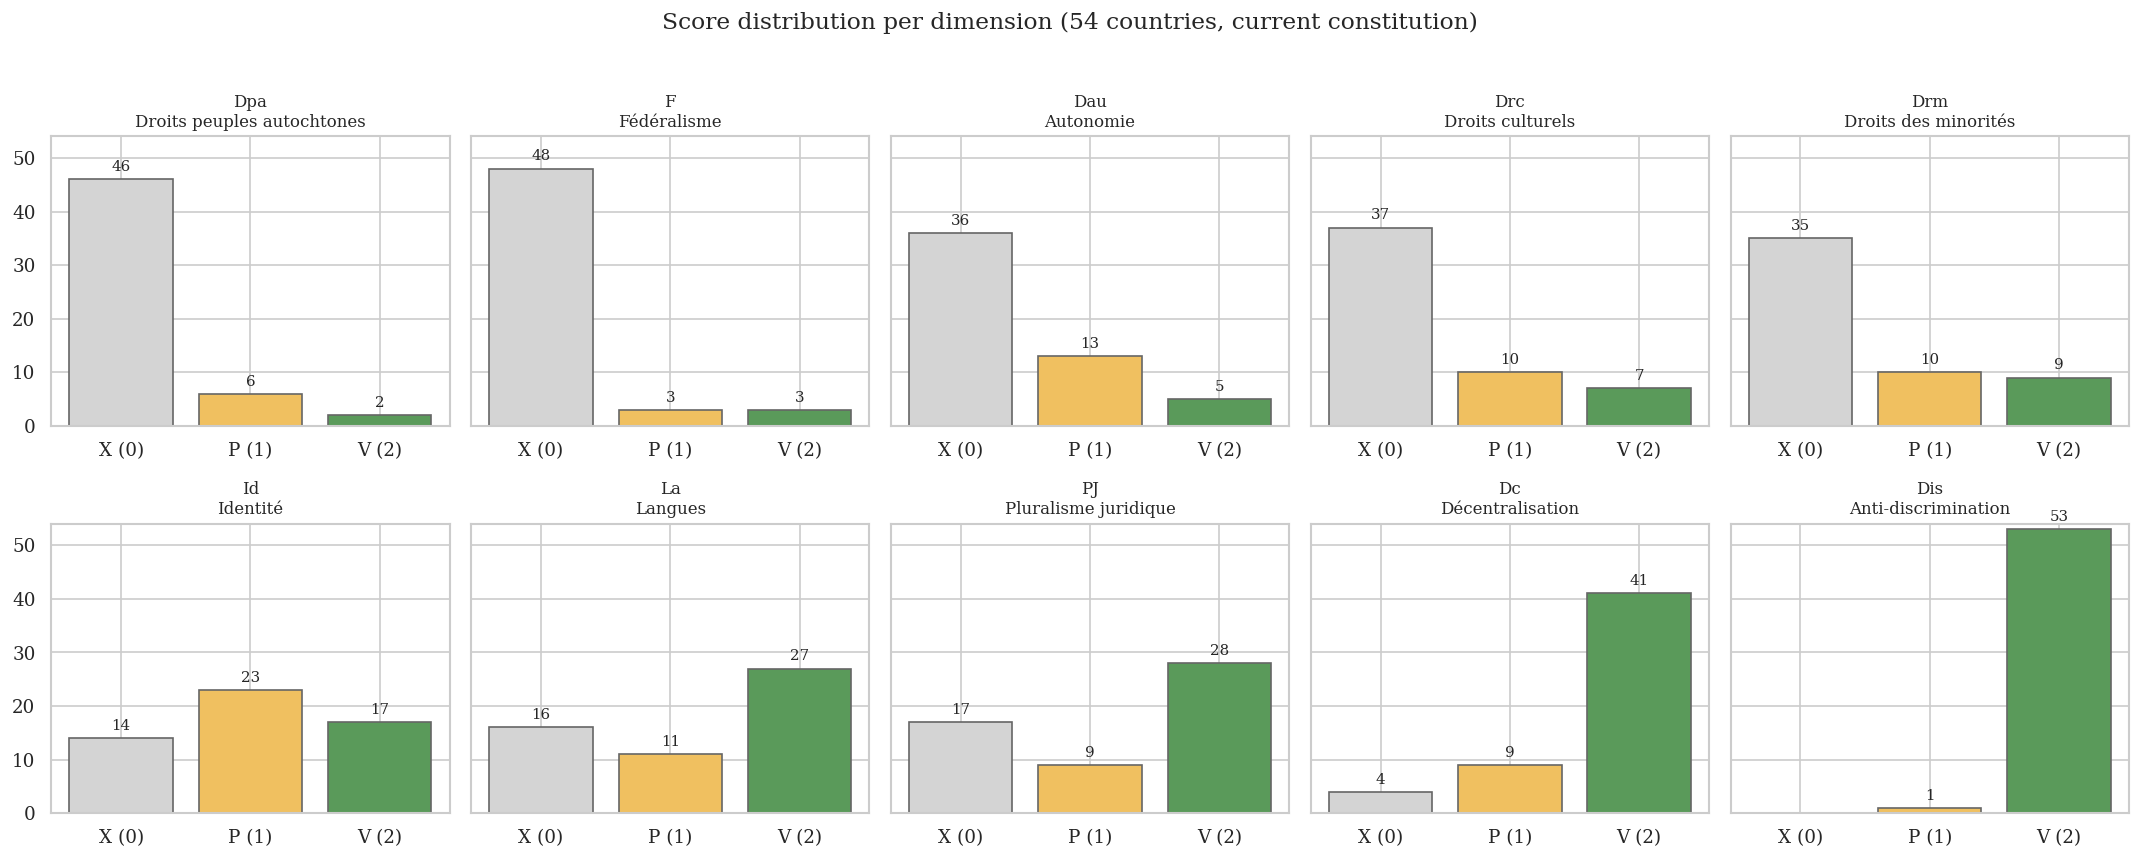


Dimension statistics (sorted by mean score):


,dimension,label,mean,median,std,pct_absent,pct_recognized
1,F,Fédéralisme,0.17,0.0,0.50,88.89,5.56
0,Dpa,Droits peuples autochtones,0.19,0.0,0.48,85.19,3.70
2,Dau,Autonomie,0.43,0.0,0.66,66.67,9.26
3,Drc,Droits culturels,0.44,0.0,0.72,68.52,12.96
4,Drm,Droits des minorités,0.52,0.0,0.77,64.81,16.67
5,Id,Identité,1.06,1.0,0.76,25.93,31.48
6,La,Langues,1.20,1.5,0.88,29.63,50.00
7,PJ,Pluralisme juridique,1.20,2.0,0.90,31.48,51.85
8,Dc,Décentralisation,1.69,2.0,0.61,7.41,75.93
9,Dis,Anti-discrimination,1.98,2.0,0.14,0.00,98.15


In [5]:
# Distribution of scores per dimension (current constitutions)
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
for i, feat in enumerate(FEATURES):
    ax = axes.flat[i]
    counts = fm[feat].value_counts().reindex([0, 1, 2], fill_value=0)
    colors = ['#d4d4d4', '#f0c060', '#5a9a5a']
    bars = ax.bar(['X (0)', 'P (1)', 'V (2)'], counts.values, color=colors, edgecolor='#666')
    ax.set_title(f"{feat}\n{LABELS[feat]}", fontsize=10)
    ax.set_ylim(0, 54)
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 1, str(val),
                    ha='center', va='bottom', fontsize=9)

fig.suptitle('Score distribution per dimension (54 countries, current constitution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
dim_stats = pd.DataFrame({
    'dimension': FEATURES,
    'label': [LABELS[f] for f in FEATURES],
    'mean': [fm[f].mean() for f in FEATURES],
    'median': [fm[f].median() for f in FEATURES],
    'std': [fm[f].std() for f in FEATURES],
    'pct_absent': [(fm[f] == 0).mean() * 100 for f in FEATURES],
    'pct_recognized': [(fm[f] == 2).mean() * 100 for f in FEATURES],
}).round(2)
dim_stats = dim_stats.sort_values('mean')
print("\nDimension statistics (sorted by mean score):")
dim_stats

/tmp/ipykernel_70528/91900042.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_by_heritage, labels=heritage_present, patch_artist=True, widths=0.6)


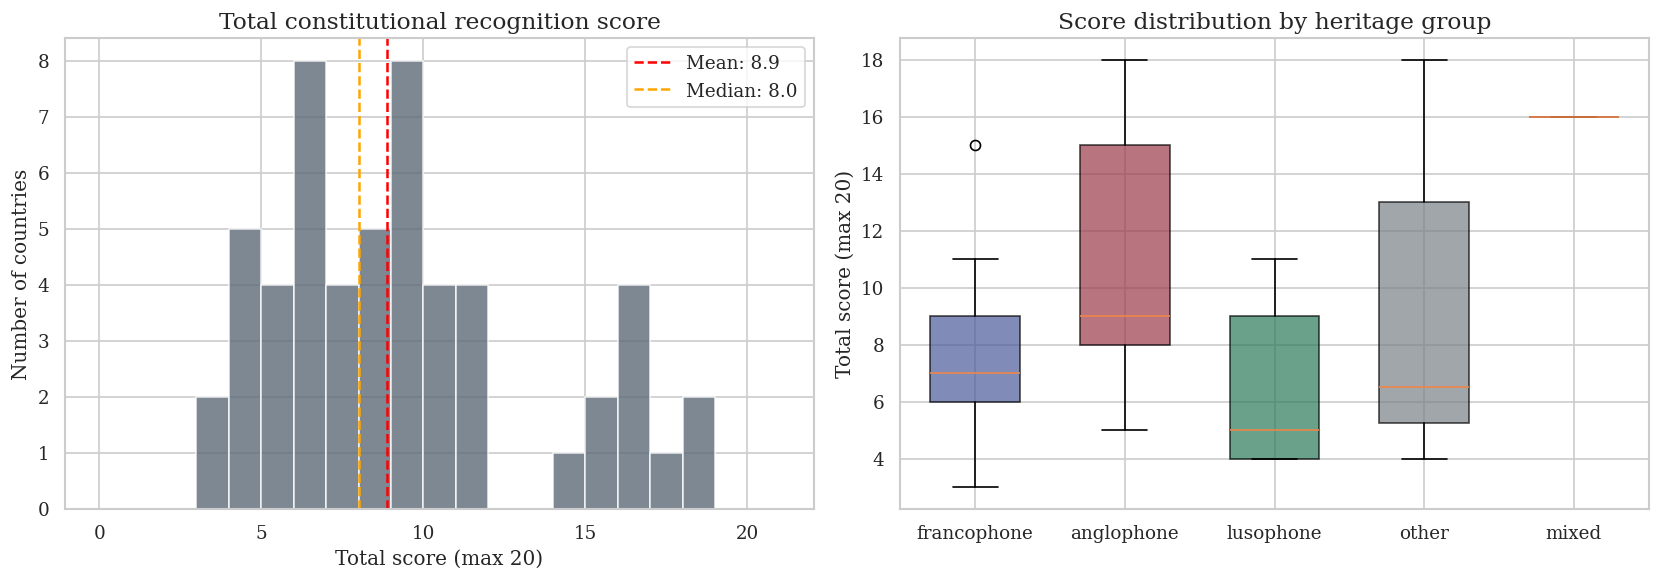


Heritage group score statistics:


,count,mean,median,std,min,max
heritage,,,,,,
francophone,23,7.30,7.0,2.85,3,15
anglophone,19,10.89,9.0,4.01,5,18
lusophone,5,6.60,5.0,3.21,4,11
other,6,9.17,6.5,5.85,4,18
mixed,1,16.00,16.0,NaN,16,16


In [6]:
# Total score distribution across 54 countries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(fm['total_score'], bins=range(0, 22), color='#5e6a78', edgecolor='white', alpha=0.8)
ax1.axvline(fm['total_score'].mean(), color='red', linestyle='--', label=f"Mean: {fm['total_score'].mean():.1f}")
ax1.axvline(fm['total_score'].median(), color='orange', linestyle='--', label=f"Median: {fm['total_score'].median():.1f}")
ax1.set_xlabel('Total score (max 20)')
ax1.set_ylabel('Number of countries')
ax1.set_title('Total constitutional recognition score')
ax1.legend()

# By heritage group
heritage_order = ['francophone', 'anglophone', 'lusophone', 'other', 'mixed']
heritage_present = [h for h in heritage_order if h in fm['heritage'].values]
data_by_heritage = [fm[fm['heritage'] == h]['total_score'].values for h in heritage_present]
bp = ax2.boxplot(data_by_heritage, labels=heritage_present, patch_artist=True, widths=0.6)
for patch, h in zip(bp['boxes'], heritage_present):
    patch.set_facecolor(HERITAGE_COLORS.get(h, '#999'))
    patch.set_alpha(0.7)
ax2.set_ylabel('Total score (max 20)')
ax2.set_title('Score distribution by heritage group')

plt.tight_layout()
plt.show()

# Heritage group statistics
heritage_stats = fm.groupby('heritage')['total_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
heritage_stats = heritage_stats.reindex(heritage_present)
print("\nHeritage group score statistics:")
heritage_stats

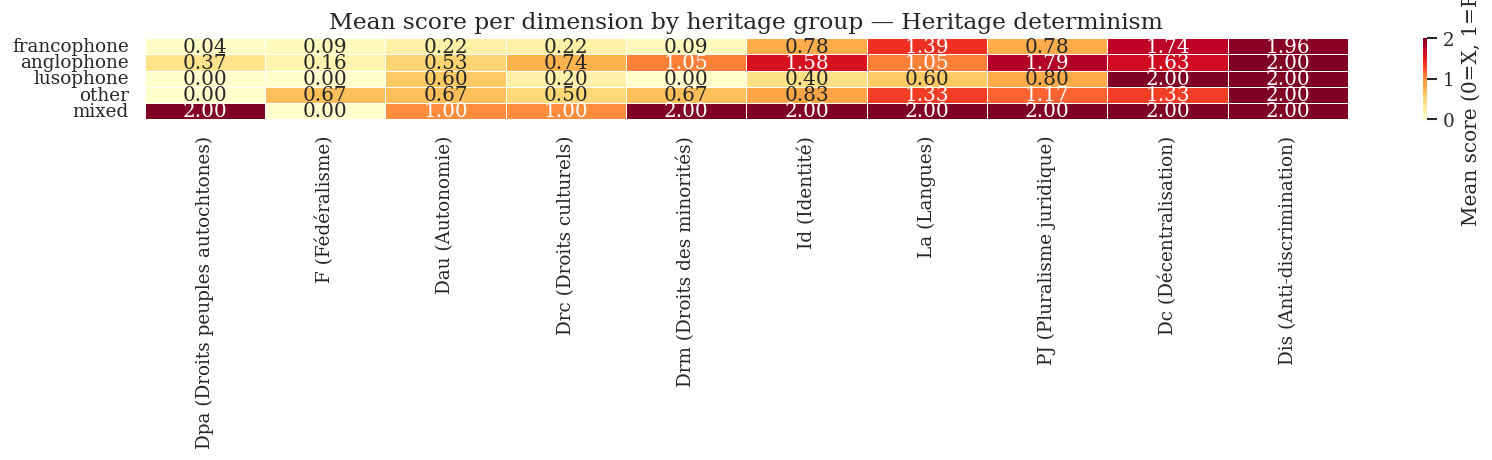


Key finding: Heritage determinism
  Francophone mean: 7.3/20
  Anglophone mean:  10.9/20
  Gap: 3.6 points


In [7]:
# Score by heritage group per dimension — the heritage determinism heatmap
heritage_dim = fm.groupby('heritage')[FEATURES].mean()
heritage_dim = heritage_dim.reindex(heritage_present)
heritage_dim.columns = [f"{f} ({LABELS[f]})" for f in FEATURES]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heritage_dim, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=2,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean score (0=X, 1=P, 2=V)'})
ax.set_title('Mean score per dimension by heritage group — Heritage determinism')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nKey finding: Heritage determinism")
print(f"  Francophone mean: {fm[fm['heritage']=='francophone']['total_score'].mean():.1f}/20")
print(f"  Anglophone mean:  {fm[fm['heritage']=='anglophone']['total_score'].mean():.1f}/20")
print(f"  Gap: {fm[fm['heritage']=='anglophone']['total_score'].mean() - fm[fm['heritage']=='francophone']['total_score'].mean():.1f} points")

In [8]:
# === Tier 1: Heritage effect size and per-dimension tests (n=42) ===
import numpy as np
from scipy.stats import mannwhitneyu

tier1 = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()
franco = tier1[tier1['heritage'] == 'francophone']
anglo = tier1[tier1['heritage'] == 'anglophone']

# Cohen's d
f_total = franco['total_score'].values
a_total = anglo['total_score'].values
pooled_std = np.sqrt(((len(f_total)-1)*f_total.std(ddof=1)**2 + (len(a_total)-1)*a_total.std(ddof=1)**2) / (len(f_total)+len(a_total)-2))
d = (a_total.mean() - f_total.mean()) / pooled_std
print(f"Cohen's d (anglo vs franco, n={len(tier1)}): {d:.2f}")
print(f"  Franco mean: {f_total.mean():.1f}, Anglo mean: {a_total.mean():.1f}")
print(f"  Pooled SD: {pooled_std:.2f}")

# Per-dimension Mann-Whitney
print(f"\nPer-dimension Mann-Whitney U (Tier 1, n={len(tier1)}):")
print(f"{'Dim':<6} {'Franco mean':>12} {'Anglo mean':>12} {'p-value':>10} {'Sig':>5}")
print("-" * 50)
for feat in FEATURES:
    f_vals = franco[feat].values
    a_vals = anglo[feat].values
    stat, p = mannwhitneyu(f_vals, a_vals, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{feat:<6} {f_vals.mean():>12.2f} {a_vals.mean():>12.2f} {p:>10.4f} {sig:>5}")

Cohen's d (anglo vs franco, n=42): 1.05
  Franco mean: 7.3, Anglo mean: 10.9
  Pooled SD: 3.42

Per-dimension Mann-Whitney U (Tier 1, n=42):
Dim     Franco mean   Anglo mean    p-value   Sig
--------------------------------------------------
Dpa            0.04         0.37     0.0201     *
F              0.09         0.16     0.8232    ns
Dau            0.22         0.53     0.0874    ns
Drc            0.22         0.74     0.0287     *
Drm            0.09         1.05     0.0000   ***
Id             0.78         1.58     0.0006   ***
La             1.39         1.05     0.1688    ns
PJ             0.78         1.79     0.0001   ***
Dc             1.74         1.63     0.5252    ns
Dis            1.96         2.00     0.3892    ns


## 3. Dimension Correlations

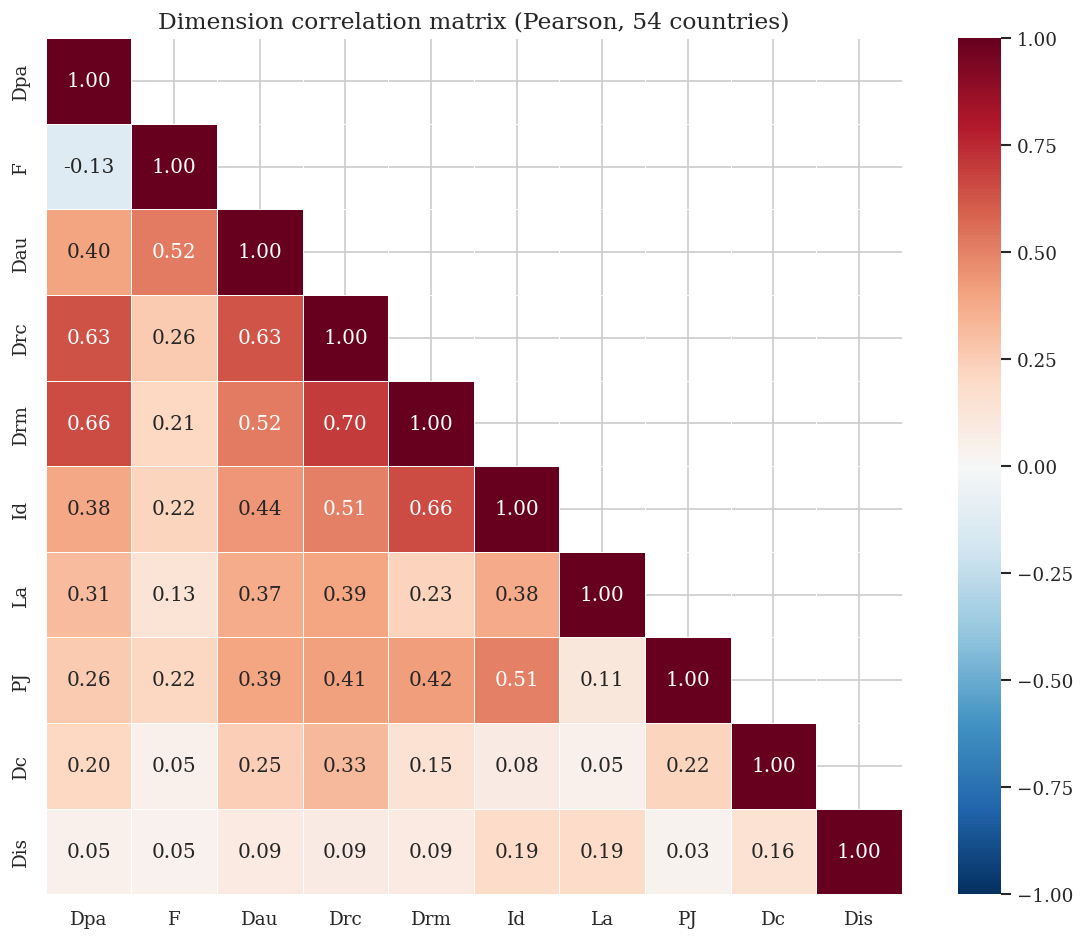


Strongest positive correlations:
  Drc  ↔ Drm   r = +0.701  (Droits culturels ↔ Droits des minorités)
  Drm  ↔ Id    r = +0.656  (Droits des minorités ↔ Identité)
  Dpa  ↔ Drm   r = +0.655  (Droits peuples autochtones ↔ Droits des minorités)
  Dpa  ↔ Drc   r = +0.634  (Droits peuples autochtones ↔ Droits culturels)
  Dau  ↔ Drc   r = +0.626  (Autonomie ↔ Droits culturels)
  Dau  ↔ Drm   r = +0.521  (Autonomie ↔ Droits des minorités)
  F    ↔ Dau   r = +0.518  (Fédéralisme ↔ Autonomie)
  Id   ↔ PJ    r = +0.506  (Identité ↔ Pluralisme juridique)
  Drc  ↔ Id    r = +0.505  (Droits culturels ↔ Identité)
  Dau  ↔ Id    r = +0.438  (Autonomie ↔ Identité)

--- Tier 1 (n=42, francophone + anglophone) ---
  Drc ↔ Drm: r = 0.69
  Dpa ↔ Drm: r = 0.68
  Drm ↔ Id: r = 0.62
Note: all-54 heatmap shown above; Tier 1 values reported for key pairs.


In [9]:
# Correlation matrix between dimensions
corr = fm[FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            xticklabels=[f"{f}" for f in FEATURES],
            yticklabels=[f"{f}" for f in FEATURES])
ax.set_title('Dimension correlation matrix (Pearson, 54 countries)')
plt.tight_layout()
plt.show()

# Top correlations
print("\nStrongest positive correlations:")
pairs = []
for i, f1 in enumerate(FEATURES):
    for j, f2 in enumerate(FEATURES):
        if i < j:
            pairs.append((f1, f2, corr.loc[f1, f2]))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, r in pairs[:10]:
    print(f"  {f1:4s} ↔ {f2:4s}  r = {r:+.3f}  ({LABELS[f1]} ↔ {LABELS[f2]})")

# --- Tier 1 correlations (francophone + anglophone only, n=42) ---
print("\n--- Tier 1 (n=42, francophone + anglophone) ---")
tier1 = fm[fm['heritage'].isin(['francophone', 'anglophone'])]
corr_t1 = tier1[FEATURES].corr()
key_pairs = [('Drc', 'Drm'), ('Dpa', 'Drm'), ('Drm', 'Id')]
for f1, f2 in key_pairs:
    print(f"  {f1} ↔ {f2}: r = {corr_t1.loc[f1, f2]:.2f}")
print("Note: all-54 heatmap shown above; Tier 1 values reported for key pairs.")

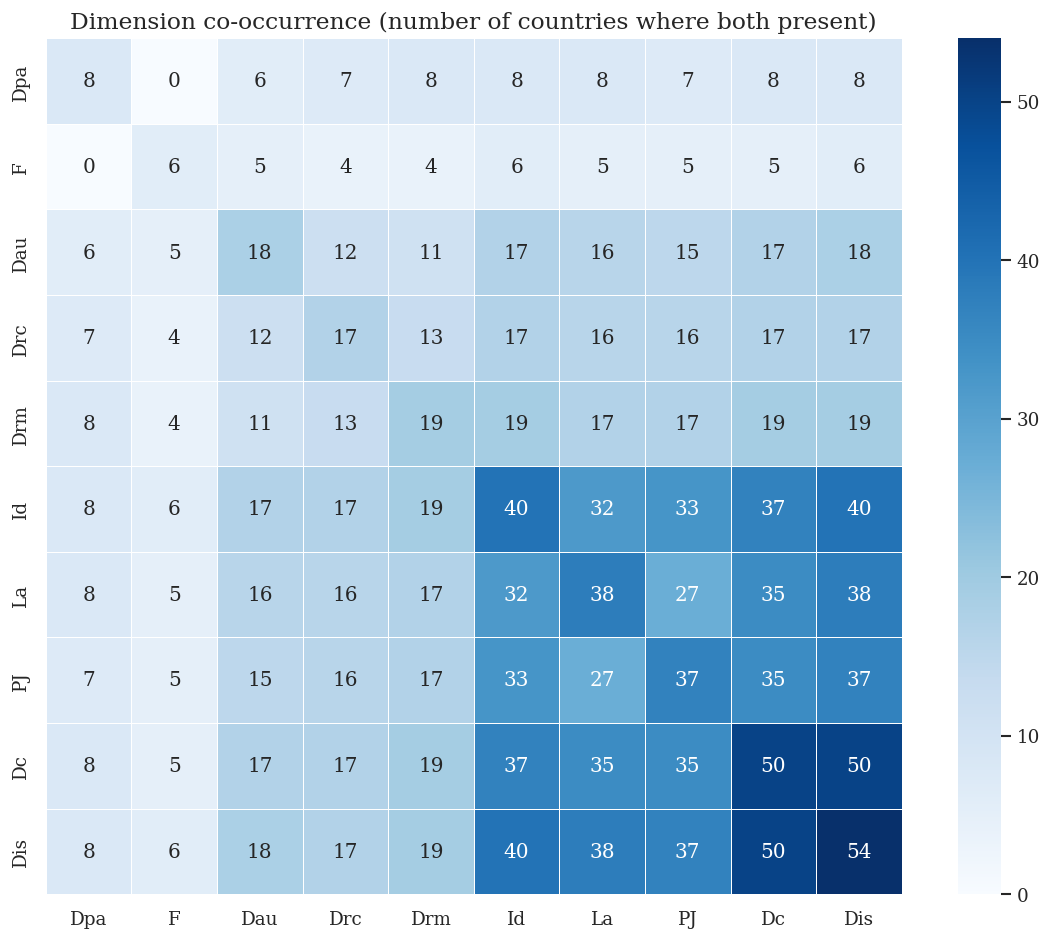


Dimension presence counts (countries where score > 0):
  Dpa  (Droits peuples autochtones    ):  8/54 (15%)
  F    (Fédéralisme                   ):  6/54 (11%)
  Dau  (Autonomie                     ): 18/54 (33%)
  Drc  (Droits culturels              ): 17/54 (31%)
  Drm  (Droits des minorités          ): 19/54 (35%)
  Id   (Identité                      ): 40/54 (74%)
  La   (Langues                       ): 38/54 (70%)
  PJ   (Pluralisme juridique          ): 37/54 (69%)
  Dc   (Décentralisation              ): 50/54 (93%)
  Dis  (Anti-discrimination           ): 54/54 (100%)


In [10]:
# Dimension co-occurrence: how often do dimensions appear together?
# Binary: present (P or V) vs absent (X)
fm_binary = (fm[FEATURES] > 0).astype(int)

co_occur = fm_binary.T @ fm_binary  # co-occurrence counts
# Normalize by minimum of marginals (Jaccard-like)
marginals = fm_binary.sum()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_occur, annot=True, fmt='d', cmap='Blues', square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Dimension co-occurrence (number of countries where both present)')
plt.tight_layout()
plt.show()

print("\nDimension presence counts (countries where score > 0):")
for f in FEATURES:
    n = (fm[f] > 0).sum()
    print(f"  {f:4s} ({LABELS[f]:30s}): {n:2d}/54 ({n/54*100:.0f}%)")

## 4. Temporal Evolution

In [11]:
# Build timeline DataFrame from country_timelines
# Features are stored as strings ('X', 'P', 'V') in timelines, need conversion
SCORE_MAP = {'X': 0, 'P': 1, 'V': 2, 0: 0, 1: 1, 2: 2}

rows = []
for country, events in DATA['country_timelines'].items():
    heritage = DATA['colonial_heritage'].get(country, 'other')
    for evt in events:
        if evt.get('has_feature_data') and evt.get('features'):
            feat = evt['features']
            scores = {f: SCORE_MAP.get(feat.get(f, 'X'), 0) for f in FEATURES}
            rows.append({
                'country': country,
                'heritage': heritage,
                'year': evt['year'],
                'total_score': sum(scores.values()),
                **scores
            })

timeline = pd.DataFrame(rows)
print(f"Timeline entries with feature data: {len(timeline)}")
print(f"Year range: {timeline['year'].min()} – {timeline['year'].max()}")
print(f"Score range: {timeline['total_score'].min()} – {timeline['total_score'].max()}")
print(f"\nEntries per decade:")
timeline['decade'] = (timeline['year'] // 10) * 10
print(timeline['decade'].value_counts().sort_index())

Timeline entries with feature data: 231
Year range: 1847 – 2024
Score range: 0 – 19

Entries per decade:
decade
1840     1
1930     1
1950    14
1960    55
1970    35
1980    18
1990    49
2000    20
2010    27
2020    11
Name: count, dtype: int64


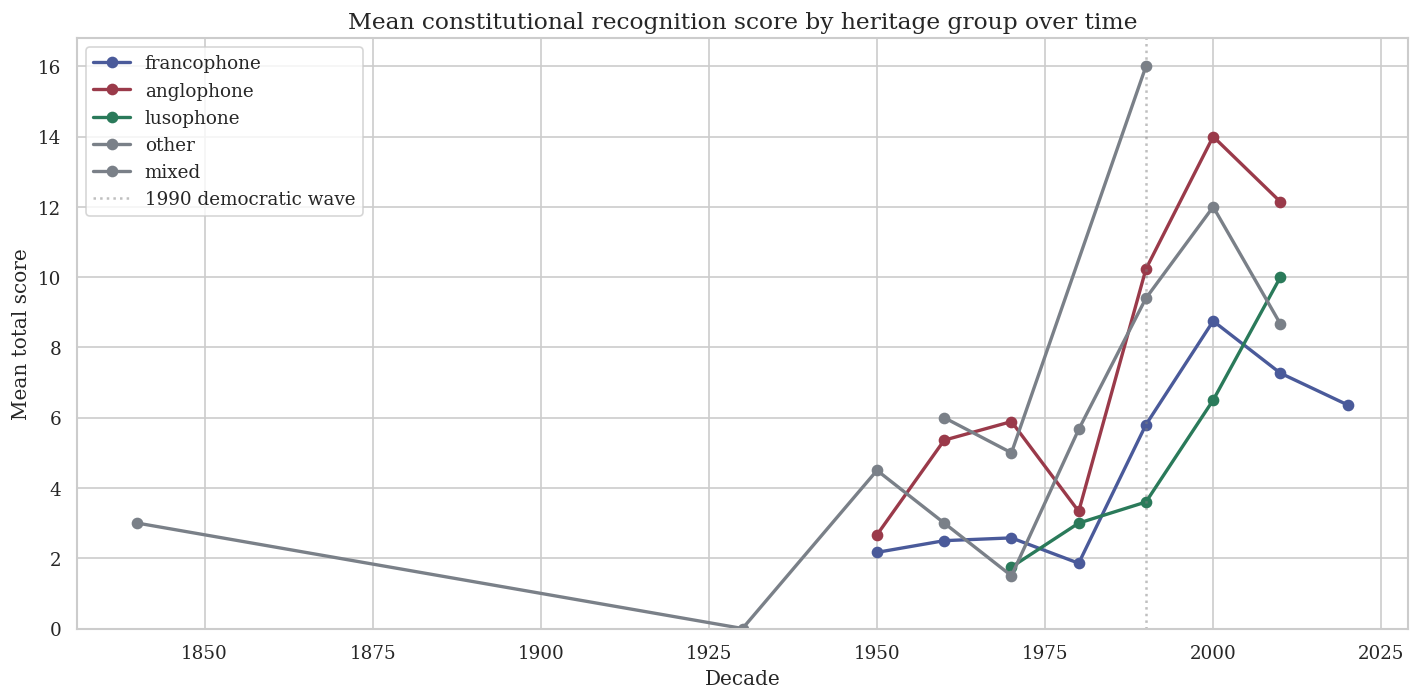


Pre-1990 vs Post-1990 mean scores by heritage:
  francophone      pre-1990:   2.4  post-1990:   6.8  change: +4.4
  anglophone       pre-1990:   4.8  post-1990:  11.5  change: +6.7
  lusophone        pre-1990:   2.2  post-1990:   5.7  change: +3.5
  other            pre-1990:   3.4  post-1990:   9.4  change: +6.1
  mixed            pre-1990:   5.7  post-1990:  16.0  change: +10.3


In [12]:
# Mean score evolution by heritage group over decades
decade_heritage = timeline.groupby(['decade', 'heritage'])['total_score'].mean().unstack()
decade_heritage = decade_heritage[[h for h in heritage_present if h in decade_heritage.columns]]

fig, ax = plt.subplots(figsize=(12, 6))
for h in decade_heritage.columns:
    mask = decade_heritage[h].notna()
    ax.plot(decade_heritage.index[mask], decade_heritage[h][mask],
            marker='o', label=h, color=HERITAGE_COLORS.get(h, '#999'), linewidth=2)
ax.axvline(1990, color='gray', linestyle=':', alpha=0.5, label='1990 democratic wave')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean total score')
ax.set_title('Mean constitutional recognition score by heritage group over time')
ax.legend()
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

# Pre/post-1990 comparison
pre90 = timeline[timeline['year'] < 1990]
post90 = timeline[timeline['year'] >= 1990]
print("\nPre-1990 vs Post-1990 mean scores by heritage:")
for h in heritage_present:
    pre = pre90[pre90['heritage'] == h]['total_score'].mean()
    post = post90[post90['heritage'] == h]['total_score'].mean()
    if not np.isnan(pre) and not np.isnan(post):
        print(f"  {h:15s}  pre-1990: {pre:5.1f}  post-1990: {post:5.1f}  change: {post-pre:+.1f}")

> **Methodological note:** This is a cross-sectional comparison (average scores in each period), not a panel analysis tracking the same countries over time. Selection effects (which countries adopted new constitutions when) are not controlled.

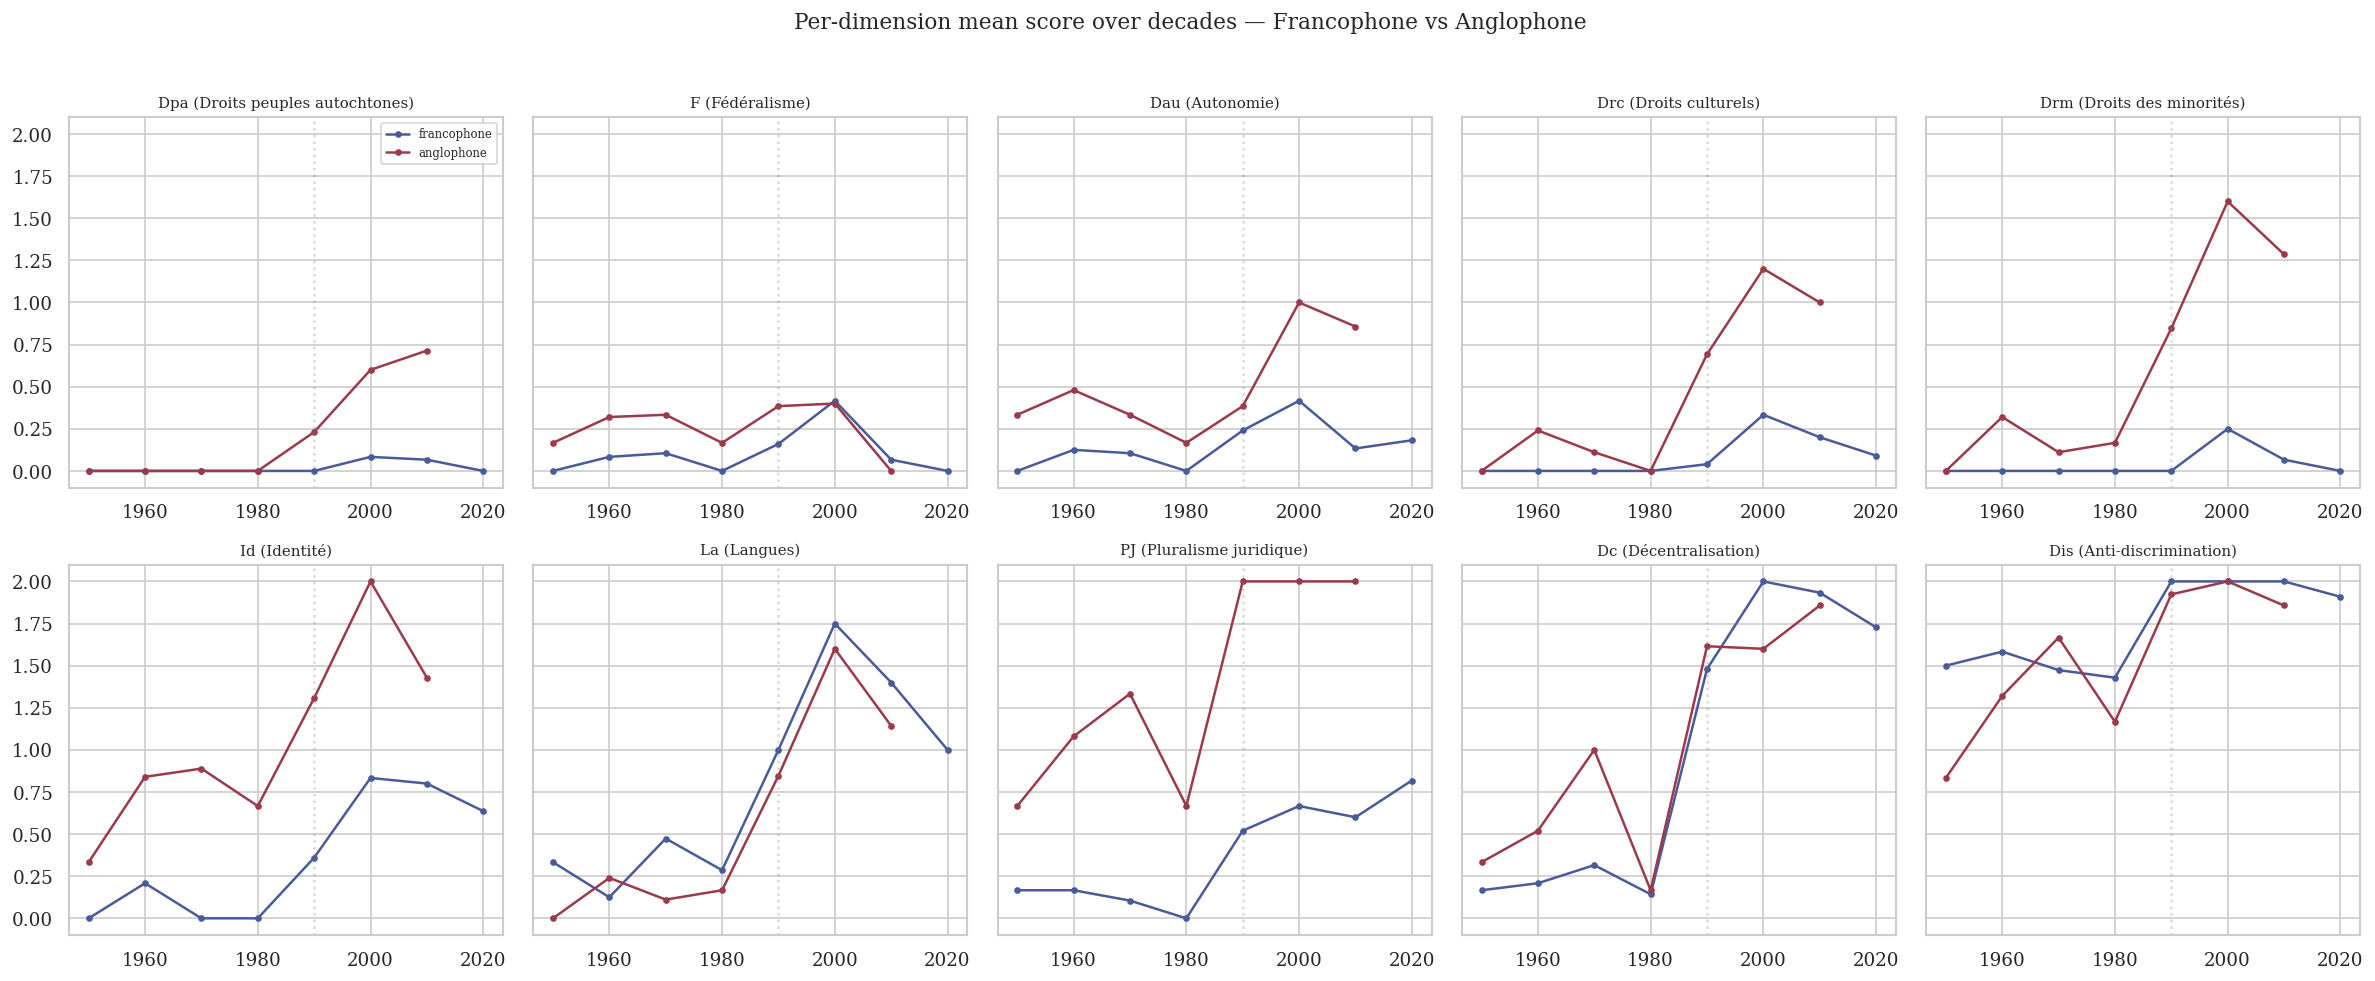

In [13]:
# Per-dimension evolution over decades (all countries)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for i, feat in enumerate(FEATURES):
    ax = axes.flat[i]
    for h in ['francophone', 'anglophone']:
        grp = timeline[timeline['heritage'] == h].groupby('decade')[feat].mean()
        mask = grp.notna()
        ax.plot(grp.index[mask], grp[mask], marker='.', label=h,
                color=HERITAGE_COLORS[h], linewidth=1.5)
    ax.set_title(f"{feat} ({LABELS[feat]})", fontsize=9)
    ax.set_ylim(-0.1, 2.1)
    ax.axvline(1990, color='gray', linestyle=':', alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle('Per-dimension mean score over decades — Francophone vs Anglophone', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Outliers and Interesting Cases

In [14]:
# Countries that deviate most from their heritage group mean
heritage_means = fm.groupby('heritage')['total_score'].mean()
fm['heritage_mean'] = fm['heritage'].map(heritage_means)
fm['deviation'] = fm['total_score'] - fm['heritage_mean']

print("Countries deviating most from heritage group mean:")
print("\n  ABOVE their heritage group (more recognition than expected):")
top = fm.nlargest(10, 'deviation')[['heritage', 'total_score', 'heritage_mean', 'deviation']]
for name, row in top.iterrows():
    print(f"    {name:25s} [{row['heritage']:12s}]  score: {row['total_score']:2.0f}  group mean: {row['heritage_mean']:.1f}  deviation: {row['deviation']:+.1f}")

print("\n  BELOW their heritage group (less recognition than expected):")
bottom = fm.nsmallest(10, 'deviation')[['heritage', 'total_score', 'heritage_mean', 'deviation']]
for name, row in bottom.iterrows():
    print(f"    {name:25s} [{row['heritage']:12s}]  score: {row['total_score']:2.0f}  group mean: {row['heritage_mean']:.1f}  deviation: {row['deviation']:+.1f}")

Countries deviating most from heritage group mean:

  ABOVE their heritage group (more recognition than expected):
    Éthiopie                  [other       ]  score: 18  group mean: 9.2  deviation: +8.8
    République démocratique du Congo [francophone ]  score: 15  group mean: 7.3  deviation: +7.7
    Kenya                     [anglophone  ]  score: 18  group mean: 10.9  deviation: +7.1
    Soudan du Sud             [anglophone  ]  score: 17  group mean: 10.9  deviation: +6.1
    Somalie                   [other       ]  score: 15  group mean: 9.2  deviation: +5.8
    Afrique du Sud            [anglophone  ]  score: 16  group mean: 10.9  deviation: +5.1
    Ouganda                   [anglophone  ]  score: 16  group mean: 10.9  deviation: +5.1
    Zimbabwe                  [anglophone  ]  score: 16  group mean: 10.9  deviation: +5.1
    Angola                    [lusophone   ]  score: 11  group mean: 6.6  deviation: +4.4
    Burundi                   [francophone ]  score: 11  group 

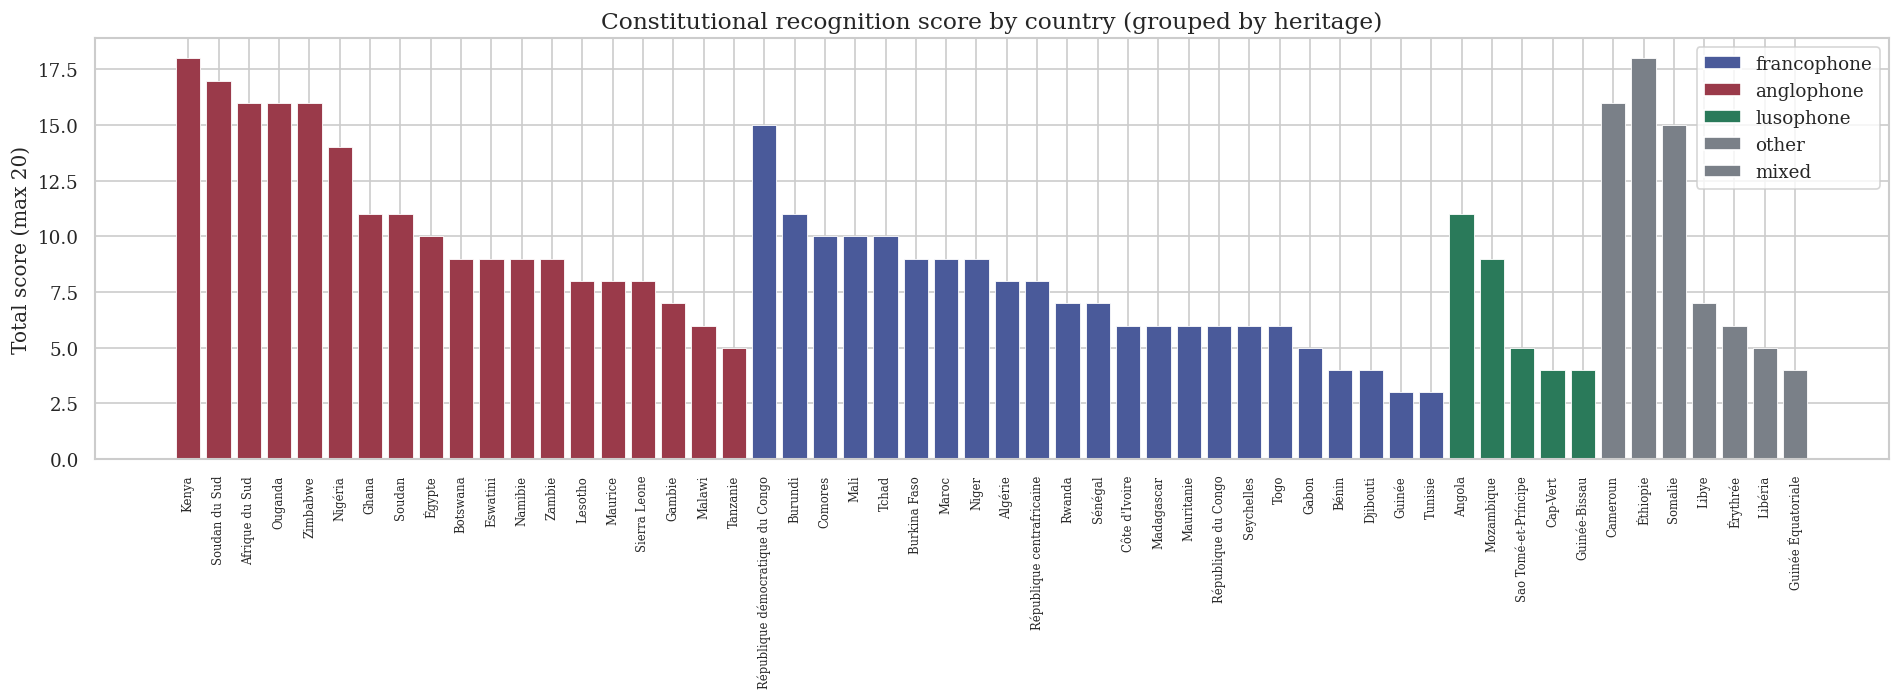

In [15]:
# Scatter: total score by country, colored by heritage, sorted within groups
fig, ax = plt.subplots(figsize=(16, 6))
fm_sorted = fm.sort_values(['heritage', 'total_score'], ascending=[True, False])
x = range(len(fm_sorted))
colors = [HERITAGE_COLORS.get(h, '#999') for h in fm_sorted['heritage']]
ax.bar(x, fm_sorted['total_score'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(fm_sorted.index, rotation=90, fontsize=7)
ax.set_ylabel('Total score (max 20)')
ax.set_title('Constitutional recognition score by country (grouped by heritage)')

# Heritage group separators
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=HERITAGE_COLORS[h], label=h) for h in heritage_present]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

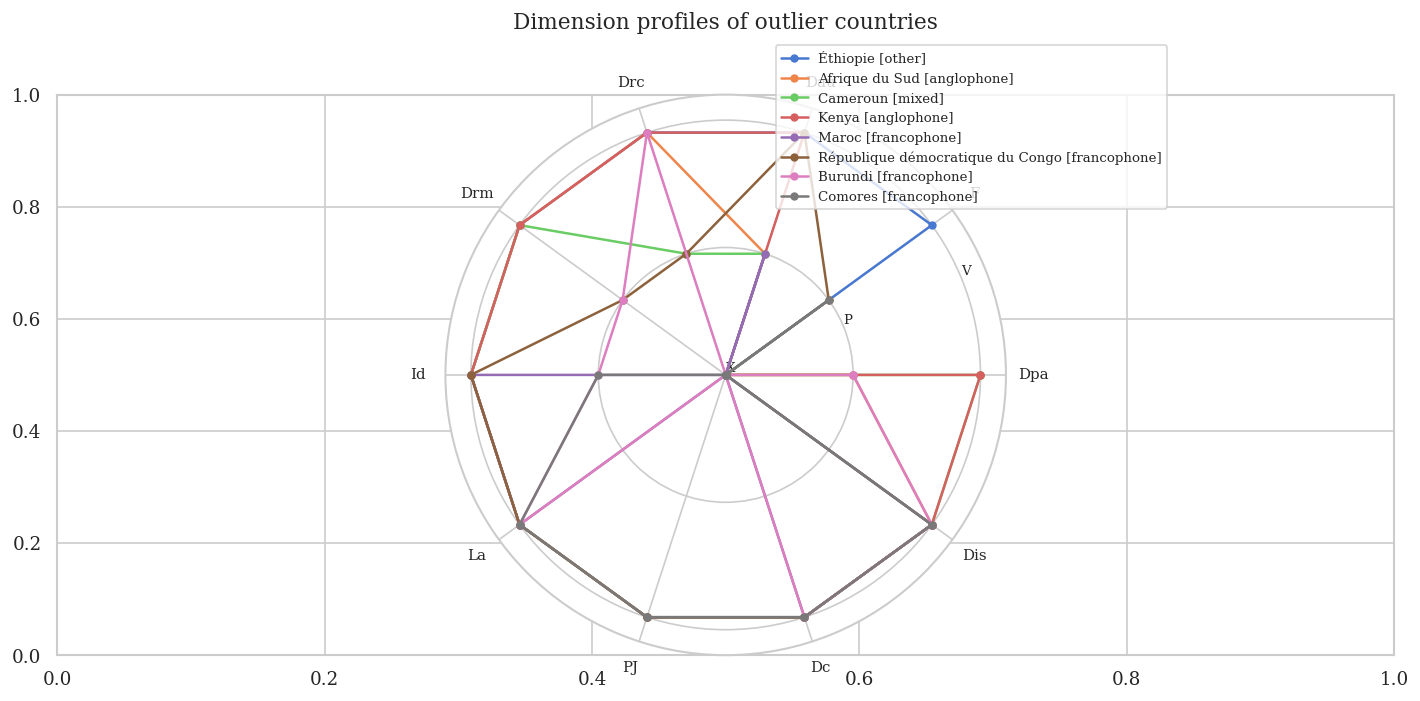

In [16]:
# Per-dimension profile for the most interesting outliers
interesting = ['Éthiopie', 'Afrique du Sud', 'Cameroun', 'Kenya', 'Maroc']
# Add the most extreme francophone outliers
franco_top = fm[fm['heritage'] == 'francophone'].nlargest(3, 'total_score').index.tolist()
anglo_bottom = fm[fm['heritage'] == 'anglophone'].nsmallest(3, 'total_score').index.tolist()
interesting = list(dict.fromkeys(interesting + franco_top + anglo_bottom))  # deduplicate, keep order
interesting = [c for c in interesting if c in fm.index]  # filter existing

fig, ax = plt.subplots(figsize=(12, 6))
angles = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for country in interesting[:8]:
    values = [fm.loc[country, f] for f in FEATURES]
    values += values[:1]
    h = fm.loc[country, 'heritage']
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values, 'o-', linewidth=1.5, label=f"{country} [{h}]", markersize=4)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURES, fontsize=9)
ax.set_ylim(0, 2.2)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['X', 'P', 'V'], fontsize=8)
ax.set_title('Dimension profiles of outlier countries', fontsize=13, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Principal Component Analysis

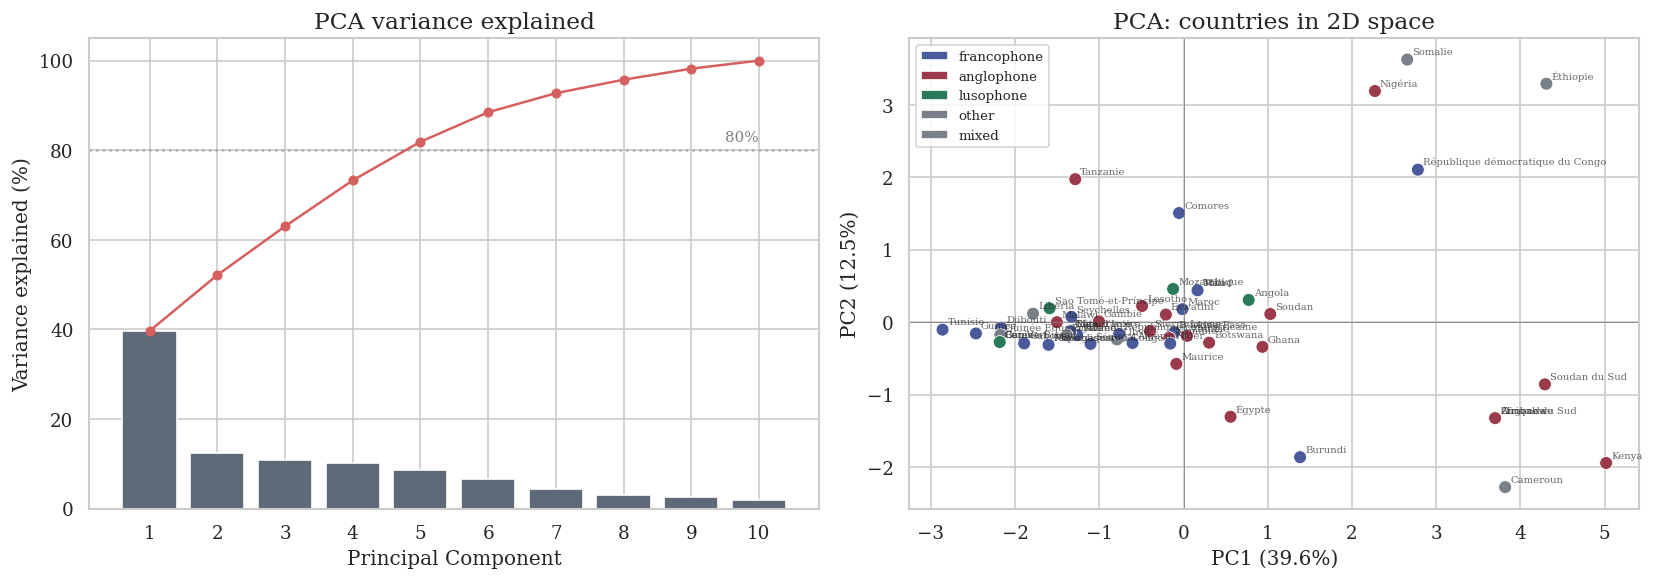


PC1 loadings (what separates countries most):
  Dpa  (Droits peuples autochtones    ): PC1=+0.345  PC2=-0.514
  F    (Fédéralisme                   ): PC1=+0.186  PC2=+0.766
  Dau  (Autonomie                     ): PC1=+0.388  PC2=+0.305
  Drc  (Droits culturels              ): PC1=+0.432  PC2=-0.094
  Drm  (Droits des minorités          ): PC1=+0.417  PC2=-0.162
  Id   (Identité                      ): PC1=+0.377  PC2=+0.010
  La   (Langues                       ): PC1=+0.252  PC2=-0.017
  PJ   (Pluralisme juridique          ): PC1=+0.302  PC2=+0.122
  Dc   (Décentralisation              ): PC1=+0.171  PC2=-0.071
  Dis  (Anti-discrimination           ): PC1=+0.099  PC2=+0.011

Does PC1 align with heritage? Correlation between PC1 score and heritage group:
  Spearman r = 0.428, p = 0.0013


In [17]:
# PCA on the 10 dimensions
X = fm[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 11), pca.explained_variance_ratio_ * 100, color='#5e6a78', edgecolor='white')
ax1.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, 'ro-', markersize=5)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance explained (%)')
ax1.set_title('PCA variance explained')
ax1.set_xticks(range(1, 11))
ax1.axhline(80, color='gray', linestyle=':', alpha=0.5)
ax1.text(9.5, 82, '80%', fontsize=9, color='gray')

# PC1 vs PC2 scatter
colors = [HERITAGE_COLORS.get(fm.iloc[i]['heritage'], '#999') for i in range(len(fm))]
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, edgecolors='white', linewidth=0.5)
for i, name in enumerate(fm.index):
    ax2.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=6, alpha=0.7,
                 xytext=(3, 3), textcoords='offset points')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title('PCA: countries in 2D space')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=HERITAGE_COLORS[h], label=h) for h in heritage_present]
ax2.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.show()

# PC loadings — what does PC1 represent?
print("\nPC1 loadings (what separates countries most):")
loadings = pd.DataFrame(pca.components_[:3].T, index=FEATURES, columns=['PC1', 'PC2', 'PC3']).round(3)
for f in FEATURES:
    print(f"  {f:4s} ({LABELS[f]:30s}): PC1={loadings.loc[f, 'PC1']:+.3f}  PC2={loadings.loc[f, 'PC2']:+.3f}")

print(f"\nDoes PC1 align with heritage? Correlation between PC1 score and heritage group:")
# Encode heritage as numeric for correlation
heritage_rank = {'francophone': 0, 'lusophone': 1, 'other': 2, 'mixed': 2, 'anglophone': 3}
h_numeric = fm['heritage'].map(heritage_rank)
r, p = stats.spearmanr(X_pca[:, 0], h_numeric)
print(f"  Spearman r = {r:.3f}, p = {p:.4f}")

## 7. Hierarchical Clustering

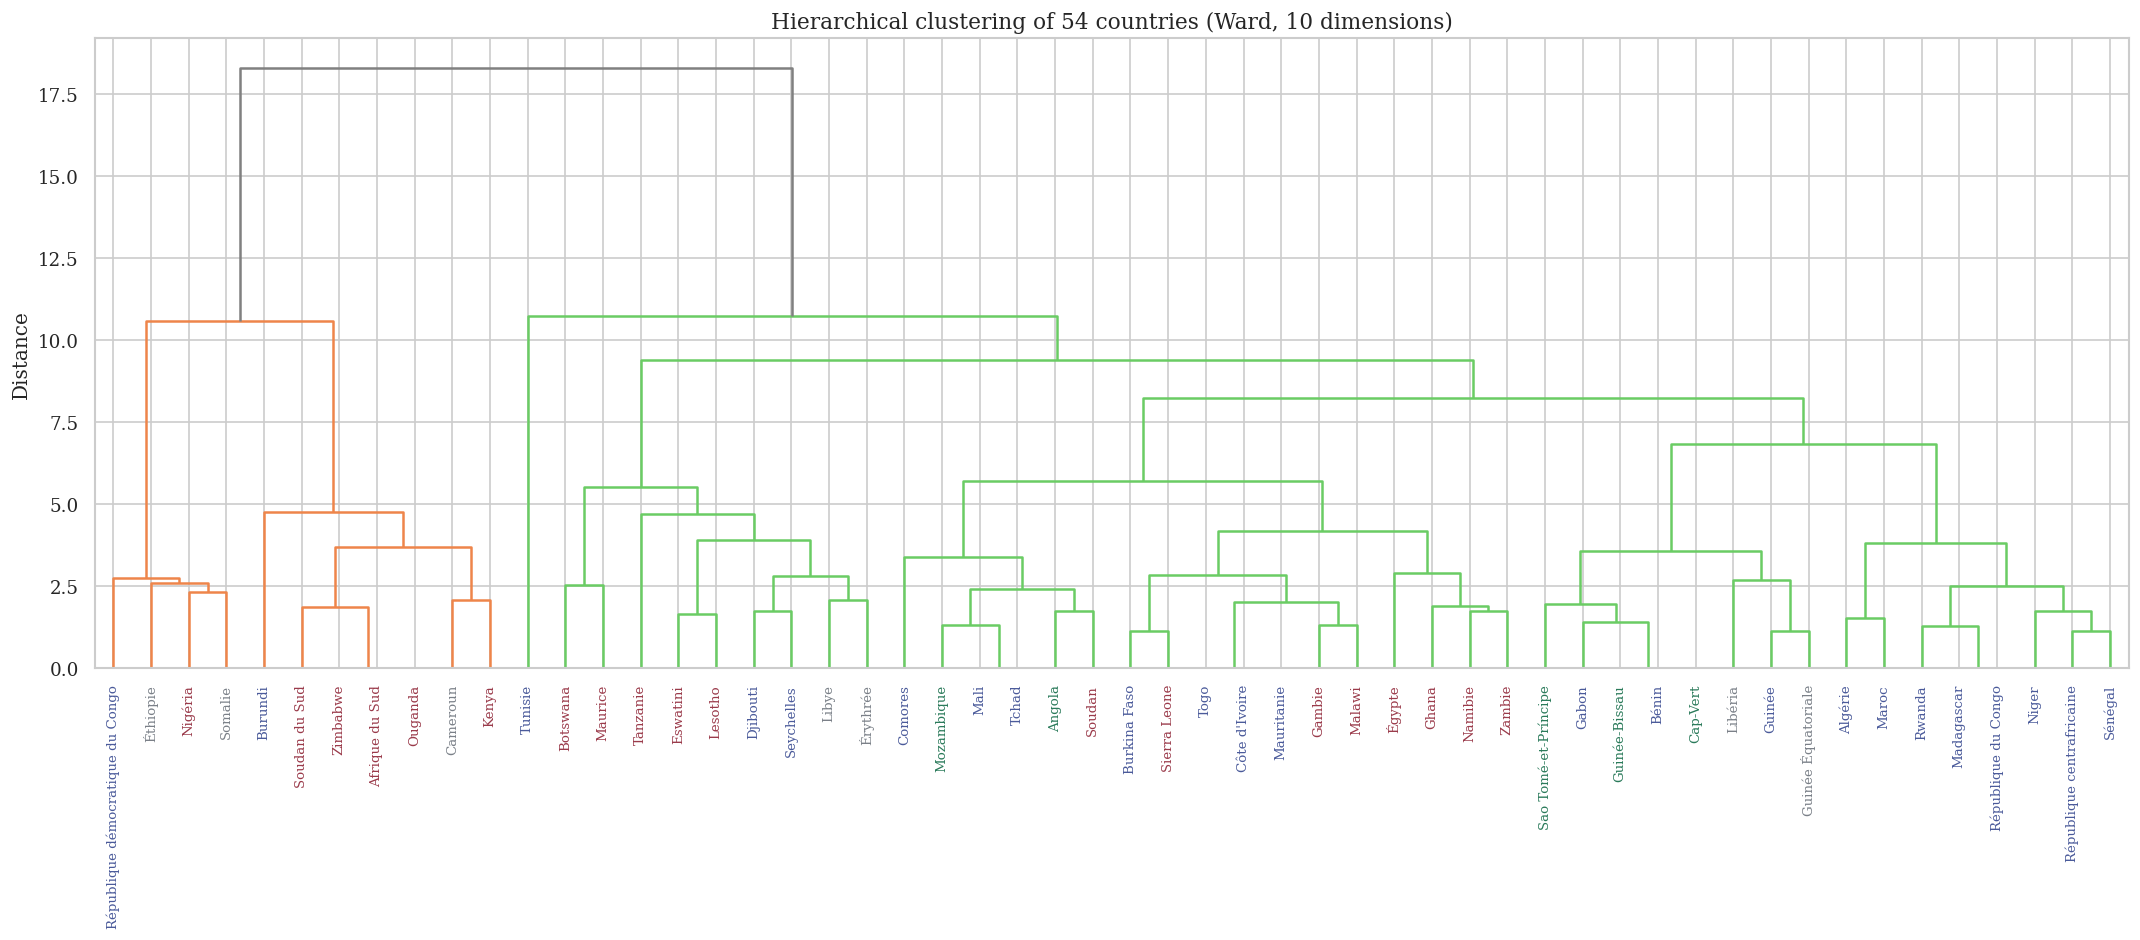


Cluster-heritage alignment (k=4):
heritage   anglophone  francophone  lusophone  mixed  other
cluster_4                                                  
1                   1            1          0      0      2
2                   5            1          0      1      0
3                  13           20          5      0      4
4                   0            1          0      0      0

Key question: Do clusters reproduce heritage groups, or reveal something new?


In [18]:
# Hierarchical clustering on the 10-dimension feature matrix
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
# Color leaves by heritage
leaf_colors = {name: HERITAGE_COLORS.get(fm.loc[name, 'heritage'], '#999') for name in fm.index}

dendro = dendrogram(Z, labels=fm.index.tolist(), leaf_rotation=90, leaf_font_size=8,
                    ax=ax, above_threshold_color='gray')

# Color the x-axis labels
xlabels = ax.get_xticklabels()
for lbl in xlabels:
    name = lbl.get_text()
    if name in leaf_colors:
        lbl.set_color(leaf_colors[name])

ax.set_title('Hierarchical clustering of 54 countries (Ward, 10 dimensions)', fontsize=13)
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Cut into k clusters
for k in [3, 4, 5]:
    clusters = fcluster(Z, k, criterion='maxclust')
    fm[f'cluster_{k}'] = clusters

# How well do clusters align with heritage?
print("\nCluster-heritage alignment (k=4):")
ct = pd.crosstab(fm['cluster_4'], fm['heritage'])
print(ct)
print(f"\nKey question: Do clusters reproduce heritage groups, or reveal something new?")


Cluster 1 (4 countries): {'other': 2, 'anglophone': 1, 'francophone': 1}
  Members: Nigéria, République démocratique du Congo, Somalie, Éthiopie

Cluster 2 (7 countries): {'anglophone': 5, 'francophone': 1, 'mixed': 1}
  Members: Afrique du Sud, Burundi, Cameroun, Kenya, Ouganda, Soudan du Sud, Zimbabwe

Cluster 3 (42 countries): {'francophone': 20, 'anglophone': 13, 'lusophone': 5, 'other': 4}
  Members: Algérie, Angola, Botswana, Burkina Faso, Bénin, Cap-Vert, Comores, Côte d'Ivoire, Djibouti, Eswatini, Gabon, Gambie, Ghana, Guinée, Guinée Équatoriale, Guinée-Bissau, Lesotho, Libye, Libéria, Madagascar, Malawi, Mali, Maroc, Maurice, Mauritanie, Mozambique, Namibie, Niger, Rwanda, République centrafricaine, République du Congo, Sao Tomé-et-Príncipe, Seychelles, Sierra Leone, Soudan, Sénégal, Tanzanie, Tchad, Togo, Zambie, Égypte, Érythrée

Cluster 4 (1 countries): {'francophone': 1}
  Members: Tunisie


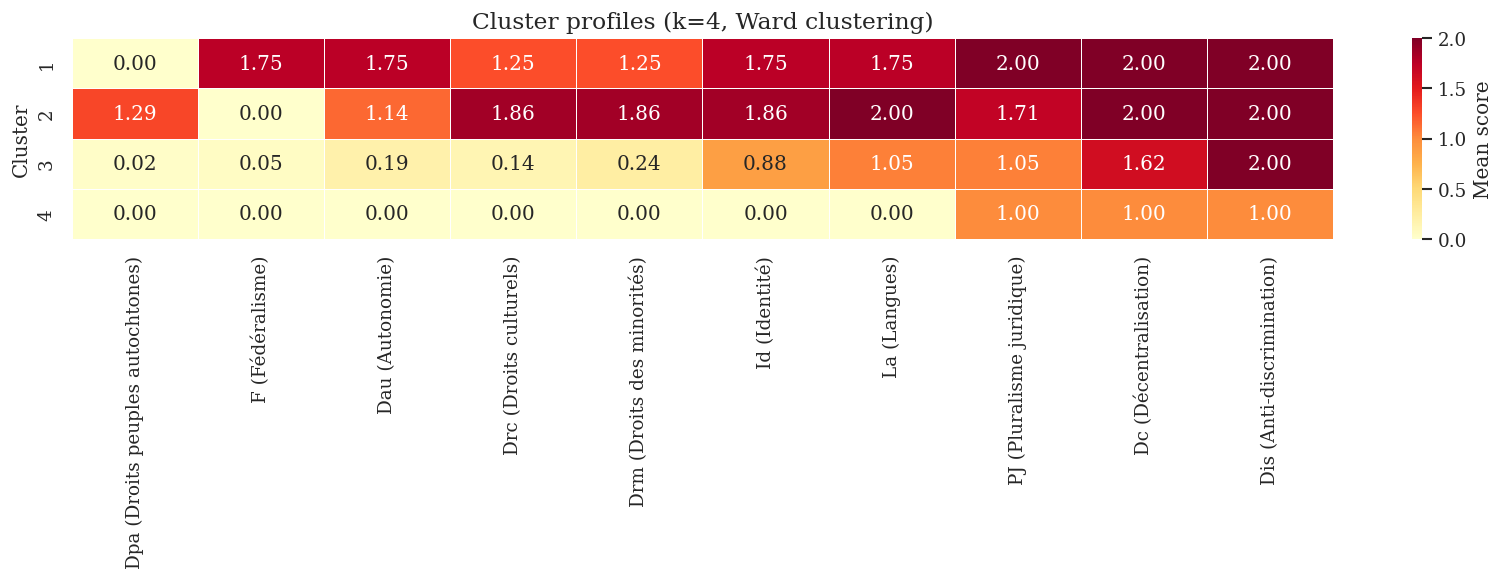

In [19]:
# Cluster profiles — what does each cluster look like?
k = 4
cluster_profiles = fm.groupby(f'cluster_{k}')[FEATURES].mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(cluster_profiles, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=2,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean score'},
            xticklabels=[f"{f} ({LABELS[f]})" for f in FEATURES])
ax.set_title(f'Cluster profiles (k={k}, Ward clustering)')
ax.set_ylabel('Cluster')

# Add cluster membership info
for c in range(1, k+1):
    members = fm[fm[f'cluster_{k}'] == c].index.tolist()
    heritages = fm[fm[f'cluster_{k}'] == c]['heritage'].value_counts().to_dict()
    print(f"\nCluster {c} ({len(members)} countries): {heritages}")
    print(f"  Members: {', '.join(sorted(members))}")

plt.tight_layout()
plt.show()

## 8. Treaty Ratification Analysis

In [20]:
# Treaty ratification data
treaties = DATA['treaties']  # ['DNUDPA', 'PIDCP', 'PIDESC', 'CERD', 'C169', 'CADHP']
treaty_labels = DATA.get('treaty_labels', {t: t for t in treaties})

# Build ratification DataFrame
ratif_rows = []
for country, ratifs in DATA['ratif_data'].items():
    row = {'country': country}
    for t in treaties:
        val = ratifs.get(t, 'X')
        row[t] = {'X': 0, 'P': 1, 'V': 2}.get(val, 0)
    row['heritage'] = DATA['colonial_heritage'].get(country, 'other')
    row['ratif_count'] = sum(1 for t in treaties if ratifs.get(t) == 'V')
    row['const_score'] = fm.loc[country, 'total_score'] if country in fm.index else None
    ratif_rows.append(row)

ratif = pd.DataFrame(ratif_rows).set_index('country')

# Treaty ratification rates
print("Treaty ratification rates (V = ratified):")
for t in treaties:
    n = (ratif[t] == 2).sum()
    print(f"  {t:8s}: {n:2d}/54 ({n/54*100:.0f}%)")

# Ratification by heritage
print("\nMean ratification count by heritage:")
print(ratif.groupby('heritage')['ratif_count'].agg(['mean', 'median']).round(1))

Treaty ratification rates (V = ratified):
  DNUDPA  : 52/54 (96%)
  PIDCP   : 51/54 (94%)
  PIDESC  : 48/54 (89%)
  CERD    : 49/54 (91%)
  C169    :  1/54 (2%)
  CADHP   : 53/54 (98%)

Mean ratification count by heritage:
             mean  median
heritage                 
anglophone    4.7     5.0
francophone   4.9     5.0
lusophone     4.2     4.0
mixed         5.0     5.0
other         4.3     4.0


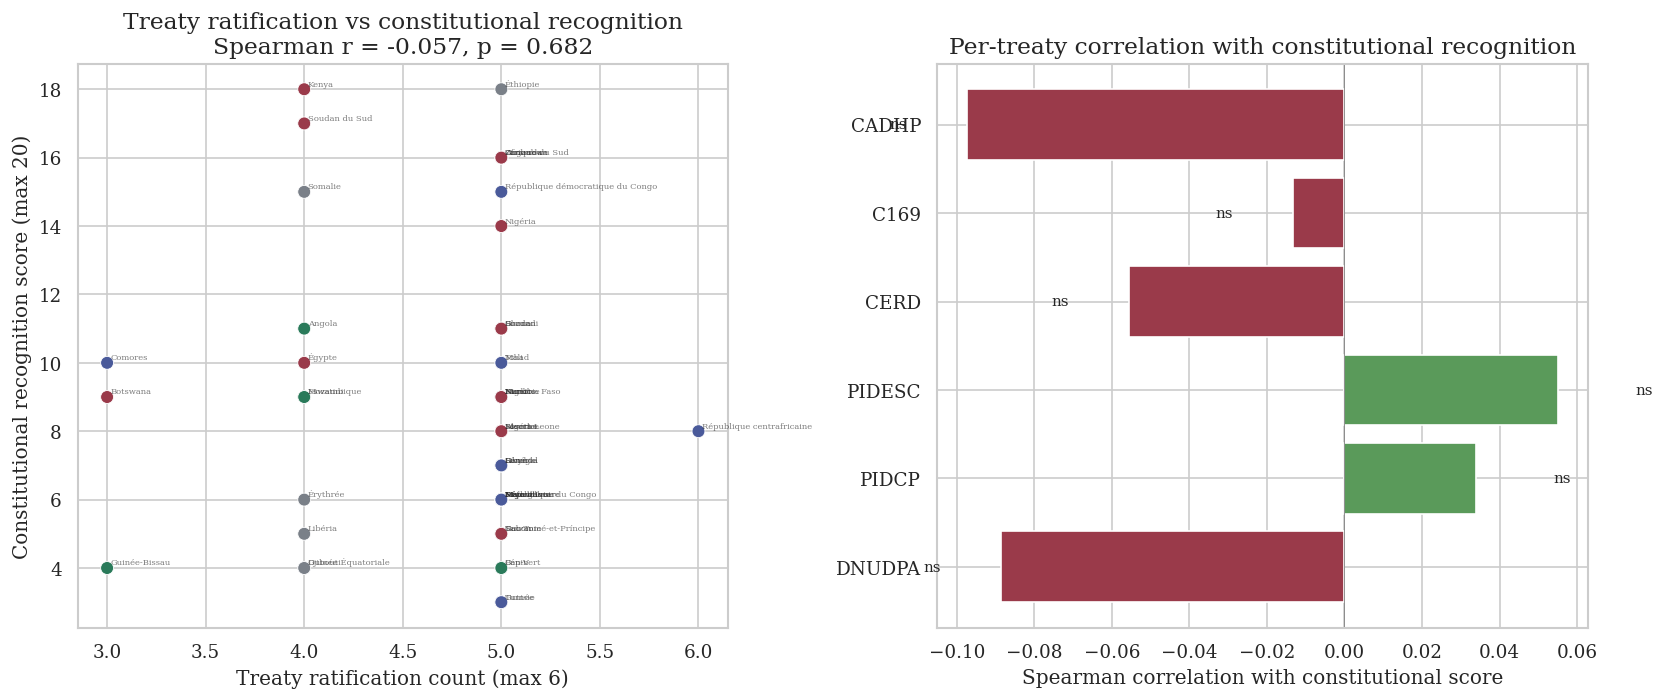


Key finding: Treaty ratification DOES NOT significantly predict constitutional recognition.
This supports the Ch.2 S1 argument that international regimes are insufficient.

Tier 1 (n=42): Spearman rho=-0.239, p=0.127
Note: all-54 result is reported because the structural argument (low variance) applies to the full dataset.


In [21]:
# The scatter plot's question: does treaty ratification predict constitutional recognition?
valid = ratif.dropna(subset=['const_score'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: constitutional score vs ratification count
colors = [HERITAGE_COLORS.get(h, '#999') for h in valid['heritage']]
ax1.scatter(valid['ratif_count'], valid['const_score'], c=colors, s=60,
            edgecolors='white', linewidth=0.5)
for name, row in valid.iterrows():
    ax1.annotate(name, (row['ratif_count'], row['const_score']),
                 fontsize=5, alpha=0.6, xytext=(2, 2), textcoords='offset points')
r, p = stats.spearmanr(valid['ratif_count'], valid['const_score'])
ax1.set_xlabel('Treaty ratification count (max 6)')
ax1.set_ylabel('Constitutional recognition score (max 20)')
ax1.set_title(f'Treaty ratification vs constitutional recognition\nSpearman r = {r:.3f}, p = {p:.3f}')

# Per-treaty correlation with total score
treaty_corrs = []
for t in treaties:
    r_t, p_t = stats.spearmanr(valid[t], valid['const_score'])
    treaty_corrs.append({'treaty': t, 'r': r_t, 'p': p_t})
tc = pd.DataFrame(treaty_corrs)
ax2.barh(tc['treaty'], tc['r'], color=['#5a9a5a' if r > 0 else '#9a3a4a' for r in tc['r']])
ax2.set_xlabel('Spearman correlation with constitutional score')
ax2.set_title('Per-treaty correlation with constitutional recognition')
ax2.axvline(0, color='gray', linewidth=0.5)
for i, row in tc.iterrows():
    sig = '***' if row['p'] < 0.001 else '**' if row['p'] < 0.01 else '*' if row['p'] < 0.05 else 'ns'
    ax2.text(row['r'] + 0.02 * np.sign(row['r']), i, sig, va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nKey finding: Treaty ratification {'DOES' if p < 0.05 else 'DOES NOT'} significantly predict constitutional recognition.")
print(f"This {'supports' if p >= 0.05 else 'challenges'} the Ch.2 S1 argument that international regimes are insufficient.")

# Tier 1 check
tier1_ratif = valid[valid['heritage'].isin(['francophone', 'anglophone'])]
rho_t1, p_t1 = stats.spearmanr(tier1_ratif['ratif_count'], tier1_ratif['const_score'])
print(f"\nTier 1 (n={len(tier1_ratif)}): Spearman rho={rho_t1:.3f}, p={p_t1:.3f}")
print("Note: all-54 result is reported because the structural argument (low variance) applies to the full dataset.")

## 9. COMMENTAIRE Column Analysis

In [22]:
# Analyze the COMMENTAIRE column — rich qualitative descriptions
comments = raw[raw['COMMENTAIRE'].notna()]['COMMENTAIRE'].astype(str)

print(f"Entries with COMMENTAIRE: {len(comments)} / {len(raw)}")
print(f"Mean length: {comments.str.len().mean():.0f} chars")
print(f"Median length: {comments.str.len().median():.0f} chars")
print(f"Max length: {comments.str.len().max():.0f} chars")

# Word frequency in comments
all_text = ' '.join(comments).lower()

# Thesis-relevant terms
thesis_terms = [
    'ethni', 'tribu', 'communaut', 'peuple', 'autochtone', 'minorit',
    'nation', 'unit', 'indivisib', 'souverain',
    'fédéral', 'décentralis', 'autonomi',
    'jacobin', 'unitaire', 'coutum', 'pluralis',
    'islam', 'chrétien', 'laïc', 'séculier',
    'langue', 'officiel', 'arabe', 'français', 'anglais', 'amazigh',
    'discrimination', 'égalité',
]

print("\nThesis-relevant term frequencies in COMMENTAIRE:")
term_counts = {}
for term in thesis_terms:
    count = len(re.findall(term, all_text, re.IGNORECASE))
    if count > 0:
        term_counts[term] = count

for term, count in sorted(term_counts.items(), key=lambda x: -x[1]):
    print(f"  {term:20s}: {count:4d}")

Entries with COMMENTAIRE: 431 / 440
Mean length: 379 chars
Median length: 324 chars
Max length: 1550 chars

Thesis-relevant term frequencies in COMMENTAIRE:
  nation              :  345
  ethni               :  229
  langue              :  209
  coutum              :  173
  unit                :  147
  discrimination      :  116
  officiel            :  109
  unitaire            :  107
  français            :   84
  décentralis         :   75
  tribu               :   70
  peuple              :   70
  autochtone          :   61
  islam               :   61
  minorit             :   59
  fédéral             :   46
  arabe               :   44
  pluralis            :   42
  communaut           :   34
  amazigh             :   33
  indivisib           :   26
  anglais             :   25
  autonomi            :   23
  jacobin             :   22
  souverain           :   20
  égalité             :   15
  laïc                :    7
  chrétien            :    6
  séculier            :    2


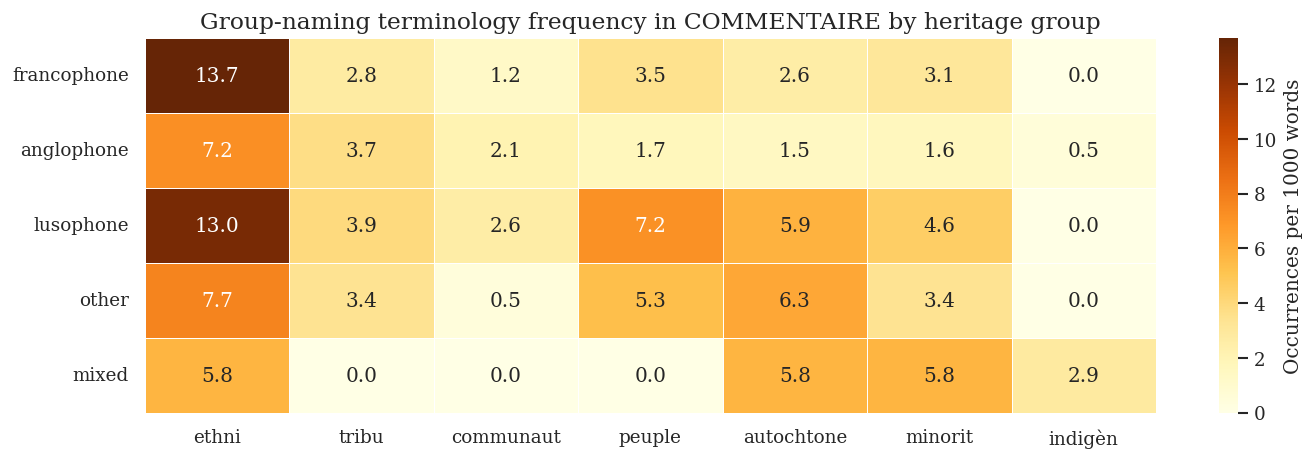

In [23]:
# Group-naming terminology by heritage: how does each heritage group's constitutions
# talk about sub-state groups?
naming_terms = ['ethni', 'tribu', 'communaut', 'peuple', 'autochtone', 'minorit', 'indigèn']

# Merge heritage info with raw data
raw_h = raw.copy()
raw_h['heritage'] = raw_h['PAYS'].map(DATA['colonial_heritage'])

# Count term occurrences per heritage group
term_by_heritage = {}
for h in heritage_present:
    h_comments = raw_h[(raw_h['heritage'] == h) & (raw_h['COMMENTAIRE'].notna())]['COMMENTAIRE'].astype(str)
    h_text = ' '.join(h_comments).lower()
    h_total_words = len(h_text.split())
    for term in naming_terms:
        count = len(re.findall(term, h_text, re.IGNORECASE))
        # Normalize per 1000 words
        normalized = (count / h_total_words * 1000) if h_total_words > 0 else 0
        if h not in term_by_heritage:
            term_by_heritage[h] = {}
        term_by_heritage[h][term] = round(normalized, 2)

term_heritage_df = pd.DataFrame(term_by_heritage).T
term_heritage_df = term_heritage_df.reindex([h for h in heritage_present if h in term_heritage_df.index])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(term_heritage_df, annot=True, fmt='.1f', cmap='YlOrBr',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Occurrences per 1000 words'})
ax.set_title('Group-naming terminology frequency in COMMENTAIRE by heritage group')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [24]:
# ARTICLES PERTINENTS analysis
articles = raw[raw['ARTICLES PERTINENTS'].notna()]['ARTICLES PERTINENTS'].astype(str)
print(f"Entries with ARTICLES PERTINENTS: {len(articles)} / {len(raw)}")

# Extract article numbers
all_articles = []
for text in articles:
    # Match patterns like 'art. 2', 'art. 10-15', 'articles 39-42'
    matches = re.findall(r'art(?:icle)?s?[.\s]+([\d]+)', text, re.IGNORECASE)
    all_articles.extend(matches)

article_counts = Counter(all_articles)
print(f"\nTotal article references extracted: {len(all_articles)}")
print(f"Unique article numbers: {len(article_counts)}")
print(f"\nMost frequently cited article numbers:")
for art, count in article_counts.most_common(20):
    print(f"  Art. {art:4s}: {count:3d} citations")

# Also check for Preamble references
preamble_refs = sum(1 for text in articles if 'préambule' in text.lower() or 'preamble' in text.lower())
print(f"\nPreamble references: {preamble_refs} / {len(articles)} ({preamble_refs/len(articles)*100:.0f}%)")

Entries with ARTICLES PERTINENTS: 423 / 440

Total article references extracted: 253
Unique article numbers: 42

Most frequently cited article numbers:
  Art. 1   : 177 citations
  Art. 2   :  13 citations
  Art. 5   :   7 citations
  Art. 3   :   6 citations
  Art. 37  :   2 citations
  Art. 26  :   2 citations
  Art. 32  :   2 citations
  Art. 6   :   2 citations
  Art. 4   :   2 citations
  Art. 102 :   2 citations
  Art. 8   :   2 citations
  Art. 29  :   2 citations
  Art. 39  :   2 citations
  Art. 46  :   2 citations
  Art. 61  :   2 citations
  Art. 27  :   2 citations
  Art. 14  :   1 citations
  Art. 38  :   1 citations
  Art. 7   :   1 citations
  Art. 157 :   1 citations

Preamble references: 93 / 423 (22%)


## 10. Missing Data and Coverage

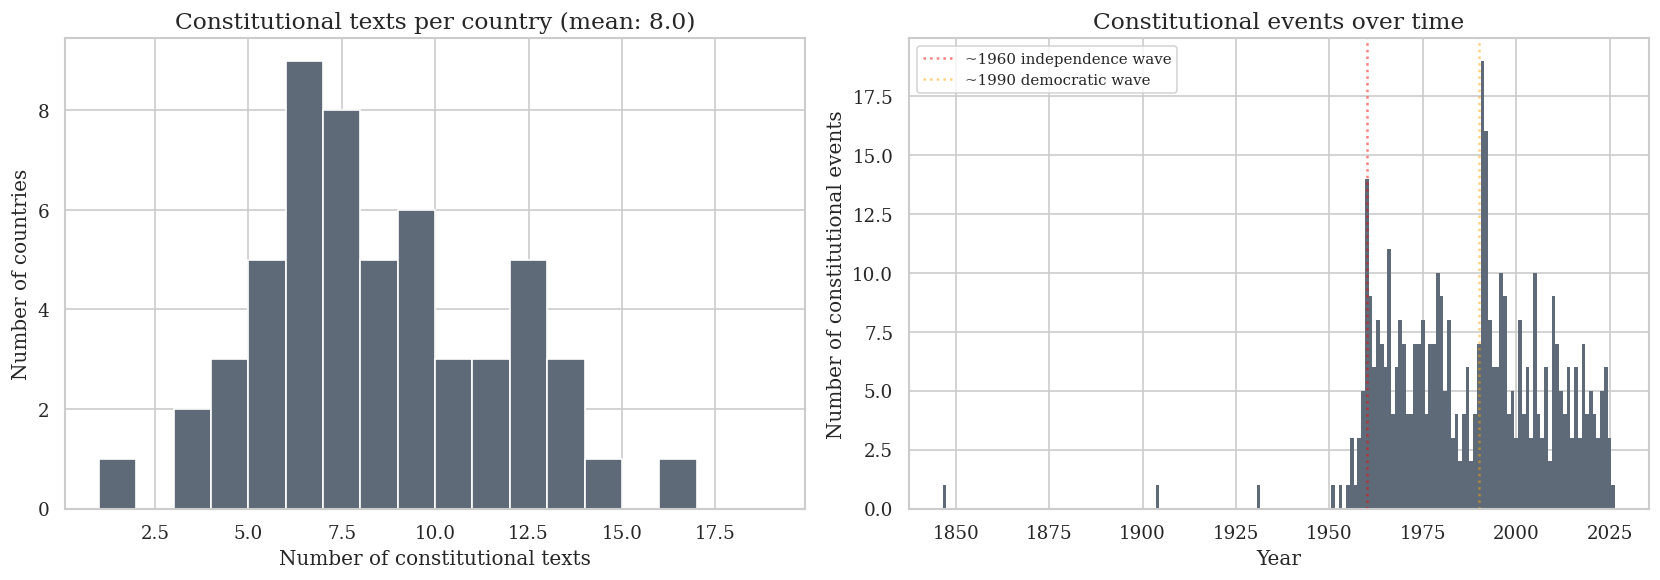

Rows with coded system data: 231 / 440 (52%)

Rows without coded features: 209
These are typically: transitional periods, coups, or suspended constitutions

Sample uncoded entries:
  Algérie              | Période Conseil de la Révolution (constitution suspendue)
  Algérie              | Révision constitutionnelle de 1979
  Algérie              | Révision constitutionnelle de 1980
  Algérie              | Révision constitutionnelle de 1988
  Algérie              | Loi n°08-19 portant révision constitutionnelle


In [25]:
# Constitutional text counts per country and decade
texts_per_country = raw.groupby('PAYS').size().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(texts_per_country, bins=range(1, 20), color='#5e6a78', edgecolor='white')
ax1.set_xlabel('Number of constitutional texts')
ax1.set_ylabel('Number of countries')
ax1.set_title(f'Constitutional texts per country (mean: {texts_per_country.mean():.1f})')

# Parse dates to get temporal coverage
# The DATE column has various formats — extract year
def extract_year(date_str):
    if pd.isna(date_str):
        return None
    match = re.search(r'(\d{4})', str(date_str))
    return int(match.group(1)) if match else None

raw['year'] = raw['DATE'].apply(extract_year)
yearly_counts = raw[raw['year'].notna()].groupby('year').size()

ax2.bar(yearly_counts.index, yearly_counts.values, color='#5e6a78', width=1, edgecolor='none')
ax2.axvline(1960, color='red', linestyle=':', alpha=0.5, label='~1960 independence wave')
ax2.axvline(1990, color='orange', linestyle=':', alpha=0.5, label='~1990 democratic wave')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of constitutional events')
ax2.set_title('Constitutional events over time')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Countries with CARACTÈRES DU SYSTÈME data
has_system = raw['CARACTÈRES DU SYSTÈME'].notna().sum()
print(f"Rows with coded system data: {has_system} / {len(raw)} ({has_system/len(raw)*100:.0f}%)")

# Check for rows WITHOUT feature data
no_features = raw[raw['CARACTÈRES DU SYSTÈME'].isna()]
print(f"\nRows without coded features: {len(no_features)}")
print(f"These are typically: transitional periods, coups, or suspended constitutions")
print(f"\nSample uncoded entries:")
for _, row in no_features.head(5).iterrows():
    name = str(row['CONSTITUTION OU LOI DE RÉVISION'])[:60] if pd.notna(row['CONSTITUTION OU LOI DE RÉVISION']) else '?'
    print(f"  {row['PAYS']:20s} | {name}")

## 11. Extended Coding Analysis (Insight #10)

Verify THESIS.md claims about extended coding sub-categories (12 total: 5 land + 7 culture).
The claim: francophone silence is on *identity*, not *culture* — cultural rights show no heritage gap.

In [26]:
# Load extended coding data
with open(PROJECT_DIR / 'data' / 'extended_coding_v2.json') as f:
    ext_raw = json.load(f)

ext_df = pd.DataFrame(ext_raw['data'])

# Sub-category columns (raw counts)
land_cats = list(ext_raw['land_categories'].keys())
culture_cats = list(ext_raw['culture_categories'].keys())
all_cats = land_cats + culture_cats

print(f'Extended coding: {len(ext_df)} countries')
print(f'Land sub-categories ({len(land_cats)}): {land_cats}')
print(f'Culture sub-categories ({len(culture_cats)}): {culture_cats}')

# Tier 1 filter
ext_t1 = ext_df[ext_df['heritage'].isin(['francophone', 'anglophone'])].copy()
franco = ext_t1[ext_t1['heritage'] == 'francophone']
anglo = ext_t1[ext_t1['heritage'] == 'anglophone']

# Mann-Whitney for each sub-category (Tier 1, using per-1k-word rates)
from scipy.stats import mannwhitneyu

print(f'\nPer-sub-category Mann-Whitney U (Tier 1, n={len(ext_t1)}):')
print(f'{"Category":<25} {"Franco mean":>12} {"Anglo mean":>12} {"p-value":>10} {"Sig":>5}')
print('-' * 70)
for cat in all_cats:
    col = cat + '_per1k'
    if col in ext_t1.columns:
        f_vals = franco[col].dropna().values
        a_vals = anglo[col].dropna().values
        if len(f_vals) > 0 and len(a_vals) > 0:
            stat, p = mannwhitneyu(f_vals, a_vals, alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            group = 'LAND' if cat in land_cats else 'CULTURE'
            print(f'{cat:<25} {f_vals.mean():>12.3f} {a_vals.mean():>12.3f} {p:>10.3f} {sig:>5}  [{group}]')

print('\n→ Cultural rights (heritage, practice, institution): all p > 0.10')
print('→ Environment: francophone constitutions mention it MORE')
print('→ The francophone silence is on identity recognition, not on culture broadly')


Extended coding: 54 countries
Land sub-categories (5): ['land_tenure', 'natural_resources', 'environment', 'water', 'territorial_integrity']
Culture sub-categories (7): ['language_official', 'language_minority', 'cultural_heritage', 'cultural_practice', 'cultural_institution', 'education_culture', 'religious_freedom']

Per-sub-category Mann-Whitney U (Tier 1, n=42):
Category                   Franco mean   Anglo mean    p-value   Sig
----------------------------------------------------------------------
land_tenure                      0.005        0.024      0.035     *  [LAND]
natural_resources                0.208        0.168      0.612    ns  [LAND]
environment                      0.804        0.414      0.003    **  [LAND]
water                            0.000        0.012      0.004    **  [LAND]
territorial_integrity            0.134        0.037      0.000   ***  [LAND]
language_official                0.023        0.002      0.145    ns  [CULTURE]
language_minority         

## 12. Religion Analysis (Insight #11)

Test whether religion (Islamic state religion vs secular/neutral) predicts constitutional recognition
independently of colonial heritage. Coding in `scripts/religion_coding.json`.

> **Preliminary:** Religion coding requires legal validation.

In [27]:
# Load religion coding
with open(PROJECT_DIR / 'scripts' / 'religion_coding.json') as f:
    religion_data = json.load(f)
religion_coding = religion_data['coding']

fm['religion'] = fm.index.map(religion_coding)
tier1 = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()

print('Tier 1 religion distribution:')
print(tier1.groupby(['heritage', 'religion']).size().unstack(fill_value=0))

# Within-heritage means
print('\nWithin-heritage mean total scores:')
for h in ['francophone', 'anglophone']:
    for rel in ['islamic', 'secular', 'neutral']:
        subset = tier1[(tier1['heritage'] == h) & (tier1['religion'] == rel)]
        if len(subset) > 0:
            print(f'  {h} {rel} (n={len(subset)}): {subset["total_score"].mean():.1f}')

# Eta-squared: heritage alone vs heritage+religion
grand_mean = tier1['total_score'].mean()
ss_total = ((tier1['total_score'] - grand_mean) ** 2).sum()

# Heritage only
ss_h = sum(len(g) * (g['total_score'].mean() - grand_mean)**2
           for _, g in tier1.groupby('heritage'))

# Heritage + religion (2×2: heritage × islamic/non-islamic)
tier1['is_islamic'] = (tier1['religion'] == 'islamic').map({True: 'islamic', False: 'non-islamic'})
ss_hr = sum(len(g) * (g['total_score'].mean() - grand_mean)**2
            for _, g in tier1.groupby(['heritage', 'is_islamic']))

eta_h = ss_h / ss_total
eta_hr = ss_hr / ss_total
increment = eta_hr - eta_h

print(f'\nEta-squared heritage: {eta_h:.3f} ({eta_h*100:.1f}%)')
print(f'Eta-squared heritage+religion: {eta_hr:.3f} ({eta_hr*100:.1f}%)')
print(f'Increment: {increment:.3f} ({increment*100:.1f}%)')

# Kruskal-Wallis: does religion predict score?
from scipy.stats import kruskal
islamic = tier1[tier1['religion'] == 'islamic']['total_score'].values
non_islamic = tier1[tier1['religion'] != 'islamic']['total_score'].values
stat, p = kruskal(islamic, non_islamic)
print(f'\nKruskal-Wallis (islamic vs non-islamic): H={stat:.2f}, p={p:.3f}')

print('\n→ Religion adds only {:.1f}% to explained variance (p={:.3f})'.format(increment*100, p))
print('→ Within each heritage group, Islamic and non-Islamic countries score similarly')
print('→ Religion is NOT an independent predictor of constitutional recognition')

Tier 1 religion distribution:
religion     islamic  neutral  secular
heritage                              
anglophone         3       16        0
francophone        6        1       16

Within-heritage mean total scores:
  francophone islamic (n=6): 6.7
  francophone secular (n=16): 7.6
  francophone neutral (n=1): 6.0
  anglophone islamic (n=3): 9.3
  anglophone neutral (n=16): 11.2

Eta-squared heritage: 0.223 (22.3%)
Eta-squared heritage+religion: 0.242 (24.2%)
Increment: 0.020 (2.0%)

Kruskal-Wallis (islamic vs non-islamic): H=0.57, p=0.450

→ Religion adds only 2.0% to explained variance (p=0.450)
→ Within each heritage group, Islamic and non-Islamic countries score similarly
→ Religion is NOT an independent predictor of constitutional recognition


## 13. Summary of Findings

### Key findings to document:

In [28]:
print("="*60)
print("EDA SUMMARY — CONSTITUTIONAL DATASET")
print("="*60)

print("\n1. HERITAGE DETERMINISM")
for h in ['francophone', 'anglophone', 'lusophone']:
    subset = fm[fm['heritage'] == h]
    print(f"   {h:15s}: mean={subset['total_score'].mean():.1f}, median={subset['total_score'].median():.1f}, std={subset['total_score'].std():.1f}")

# Statistical test
f_scores = fm[fm['heritage'] == 'francophone']['total_score']
a_scores = fm[fm['heritage'] == 'anglophone']['total_score']
u_stat, u_p = stats.mannwhitneyu(f_scores, a_scores, alternative='two-sided')
print(f"   Mann-Whitney U test (franco vs anglo): U={u_stat:.0f}, p={u_p:.6f}")

# Kruskal-Wallis across all groups
groups = [fm[fm['heritage'] == h]['total_score'].values for h in heritage_present if len(fm[fm['heritage'] == h]) >= 3]
h_stat, kw_p = stats.kruskal(*groups)
print(f"   Kruskal-Wallis (all groups): H={h_stat:.1f}, p={kw_p:.6f}")
print("   Note: Kruskal-Wallis is exploratory (all heritage groups incl. lusophone/other).")
print(f"   Tier 1 Mann-Whitney (franco vs anglo, n={len(f_scores)+len(a_scores)}): U={u_stat:.0f}, p={u_p:.6f} ← primary test")

print("\n2. DIMENSION STRUCTURE")
print(f"   Most absent: {dim_stats.iloc[0]['dimension']} ({dim_stats.iloc[0]['label']}) — {dim_stats.iloc[0]['pct_absent']:.0f}% absent")
print(f"   Most recognized: {dim_stats.iloc[-1]['dimension']} ({dim_stats.iloc[-1]['label']}) — {dim_stats.iloc[-1]['pct_recognized']:.0f}% fully recognized")

print("\n3. TOP CORRELATIONS")
for f1, f2, r in pairs[:5]:
    print(f"   {f1} ↔ {f2}: r={r:.3f}")

print("\n4. PCA")
print(f"   PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"   First 3 PCs explain {sum(pca.explained_variance_ratio_[:3])*100:.1f}% of variance")

print("\n5. TREATY-CONSTITUTIONAL CORRELATION")
r_overall, p_overall = stats.spearmanr(valid['ratif_count'], valid['const_score'])
print(f"   Overall: r={r_overall:.3f}, p={p_overall:.3f}")

print("\n6. IMPLICATIONS FOR SUBSEQUENT MILESTONES")
print("   M0 (scatter): Use the treaty-constitutional correlation statistics above")
print("   M2 (NLP): COMMENTAIRE terminology analysis suggests heritage-specific naming patterns")
print("   M4 (clustering): PCA and hierarchical clustering reveal whether heritage is the primary axis")
print("   M4 (treaty gap): Per-treaty correlations inform which treaties to highlight")

EDA SUMMARY — CONSTITUTIONAL DATASET

1. HERITAGE DETERMINISM
   francophone    : mean=7.3, median=7.0, std=2.9
   anglophone     : mean=10.9, median=9.0, std=4.0
   lusophone      : mean=6.6, median=5.0, std=3.2
   Mann-Whitney U test (franco vs anglo): U=105, p=0.004054
   Kruskal-Wallis (all groups): H=9.4, p=0.024472
   Note: Kruskal-Wallis is exploratory (all heritage groups incl. lusophone/other).
   Tier 1 Mann-Whitney (franco vs anglo, n=42): U=105, p=0.004054 ← primary test

2. DIMENSION STRUCTURE
   Most absent: F (Fédéralisme) — 89% absent
   Most recognized: Dis (Anti-discrimination) — 98% fully recognized

3. TOP CORRELATIONS
   Drc ↔ Drm: r=0.701
   Drm ↔ Id: r=0.656
   Dpa ↔ Drm: r=0.655
   Dpa ↔ Drc: r=0.634
   Dau ↔ Drc: r=0.626

4. PCA
   PC1 explains 39.6% of variance
   First 3 PCs explain 63.0% of variance

5. TREATY-CONSTITUTIONAL CORRELATION
   Overall: r=-0.057, p=0.682

6. IMPLICATIONS FOR SUBSEQUENT MILESTONES
   M0 (scatter): Use the treaty-constitutional cor